In [111]:
import os
import numpy as np
import pandas as pd
import pybedtools
import ast
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm

import itertools

# allow imports from utils/
import sys
from pathlib import Path
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

In [2]:
# Parameters
resol = 250000

# Load data

## Chromosome sizes


In [82]:
# First, we load chromosome sizes obtined from the UCSC genome browser.
chromsize_df = pd.read_csv(
    '../data/genome_data/hg19/chrom_hg19.sizes',
    sep='\t'
)
chromsize_df = chromsize_df[['chrom', 'size']]
chromsize_df = chromsize_df[chromsize_df['chrom'].isin(['chr'+str(i) for i in np.arange(1, 22+1, 1)])]

# Divide the chromosomes into loci and make bed file.
df_chrom_list = []
for chrom_id in np.arange(1, 22+1):
    chrom = f'chr{chrom_id}'
    chrom_size = chromsize_df[chromsize_df['chrom']==chrom]['size'].values[0]
    stop_pos = np.arange(resol, chrom_size + resol, resol, dtype = 'int')
    df_chrom = pd.DataFrame()
    df_chrom['chrom'] = [chrom]*len(stop_pos)
    df_chrom['start'] = stop_pos - resol
    df_chrom['stop'] = stop_pos
    df_chrom_list.append(df_chrom)
segment_df = pd.concat(df_chrom_list, axis=0)
bed_segment = pybedtools.BedTool.from_dataframe(segment_df).sort()

## IMR90 LAS data

In [3]:
dir_las = '../data/imr90/hic/processed/pval_threshold_0.9999999999/'
# LAS matrices
las_df = pd.read_csv(dir_las+'all_thresholded_las_pixels.csv', header=0, index_col=0, sep=',')
las_df.loc[:, 'las_submat'] = las_df['las_submat'].astype(str)
las_df.loc[:, 'avg'] = las_df['hic']
las_df = las_df.drop(['hic'], axis=1)
print(f'Number of LAS submatrices = {las_df.shape[0]}')
las_df.head()

Number of LAS submatrices = 381860


,region,las_interacting_region1,chr1,chr1_start,chr1_end,las_interacting_region2,chr2,chr2_start,chr2_end,score,neglogpval,avg,las_submat
0,chr1_3_4_chr2_965_966,las_chr1_750000_1000000,chr1,750000,1000000,las_chr2_241250000_241500000,chr2,241250000,241500000,272.39041,286.165339,2.127030,0
1,chr1_3_4_chr2_966_967,las_chr1_750000_1000000,chr1,750000,1000000,las_chr2_241500000_241750000,chr2,241500000,241750000,272.39041,286.165339,2.075072,0
2,chr1_3_4_chr2_967_968,las_chr1_750000_1000000,chr1,750000,1000000,las_chr2_241750000_242000000,chr2,241750000,242000000,272.39041,286.165339,1.860178,0
3,chr1_3_4_chr2_968_969,las_chr1_750000_1000000,chr1,750000,1000000,las_chr2_242000000_242250000,chr2,242000000,242250000,272.39041,286.165339,2.698318,0
4,chr1_3_4_chr2_969_970,las_chr1_750000_1000000,chr1,750000,1000000,las_chr2_242250000_242500000,chr2,242250000,242500000,272.39041,286.165339,2.620896,0


In [4]:
interacting_regions_df = pd.read_csv(dir_las+'all_thresholded_las_interacting_pixels.csv', header=0, index_col=0)
interacting_regions_bed = pybedtools.BedTool.from_dataframe(interacting_regions_df).sort()
interacting_regions_df.head()

,chrom,chromStart,chromEnd,name
0,chr1,750000,1000000,las_chr1_750000_1000000
1,chr1,1000000,1250000,las_chr1_1000000_1250000
2,chr1,1250000,1500000,las_chr1_1250000_1500000
3,chr1,1500000,1750000,las_chr1_1500000_1750000
4,chr1,1750000,2000000,las_chr1_1750000_2000000


## ncRNA binding sites

In [5]:
# ncRNA transcription sites and binding sites
ncrna_df = pd.read_csv('../data/imr90/imr90_specific_ncrna_dna_bs_data_all_expressed.csv.gz',
                       header=0, index_col=None)
ncrna_df = ncrna_df[
    ['ncID_ensembl', 'tss', 'tes', 'ts_chromosome', 'ts_length', 'ts_loci',
     'ia_chromosome', 'iass', 'iaes', 'ia_length', 'ia_loci', 'closest_gene']
]
all_ncrnas = ncrna_df['ncID_ensembl'].unique()
ncrna_df.head()

,ncID_ensembl,tss,tes,ts_chromosome,ts_length,ts_loci,ia_chromosome,iass,iaes,ia_length,ia_loci,closest_gene
0,ENSG00000245017,98879321.0,98897633.0,12,18312.0,['chr12_loc_98750000'],1,1473892,1473926,34,['chr1_loc_1250000'],ENSG00000205090
1,ENSG00000245017,98879321.0,98897633.0,12,18312.0,['chr12_loc_98750000'],1,2567807,2567905,98,['chr1_loc_2500000'],ENSG00000237058
2,ENSG00000245017,98879321.0,98897633.0,12,18312.0,['chr12_loc_98750000'],1,6903425,6903523,98,['chr1_loc_6750000'],ENSG00000171735
3,ENSG00000245017,98879321.0,98897633.0,12,18312.0,['chr12_loc_98750000'],1,7546356,7546415,59,['chr1_loc_7500000'],ENSG00000171735
4,ENSG00000245017,98879321.0,98897633.0,12,18312.0,['chr12_loc_98750000'],1,8656298,8656354,56,['chr1_loc_8500000'],ENSG00000142599


In [6]:
# Create dictionary mapping each ncRNA to its TS loci
df = ncrna_df[['ncID_ensembl', 'ts_loci']].drop_duplicates()
ncrna2ts = {ncrna_df.loc[idx, 'ncID_ensembl']: ast.literal_eval(ncrna_df.loc[idx, 'ts_loci']) for idx in df.index}

# Create BED object for ncRNA transcription sites
ncrna_ts_df = ncrna_df[['ncID_ensembl', 'ts_chromosome', 'tss', 'tes']].copy()
ncrna_ts_df.columns = ['name', 'chrom', 'chromStart', 'chromEnd']
ncrna_ts_df = ncrna_ts_df[['chrom', 'chromStart', 'chromEnd', 'name']]
ncrna_ts_df['chrom'] = 'chr'+ncrna_ts_df['chrom'].astype(str)
ncrna_ts_df['chromStart'] = ncrna_ts_df['chromStart'].astype(int)
ncrna_ts_df['chromEnd'] = ncrna_ts_df['chromEnd'].astype(int)
ncrna_ts_df = ncrna_ts_df.drop_duplicates()
ncrna_ts_df = ncrna_ts_df.reset_index(drop=True)
ncrna_ts_bed = pybedtools.BedTool.from_dataframe(ncrna_ts_df).sort()
ncrna_ts_df.head()

# Create BED object for ncRNA binding sites
ncrna_bs_df = ncrna_df[['ncID_ensembl', 'ia_chromosome', 'iass', 'iaes']].copy()
ncrna_bs_df.columns = ['name', 'chrom', 'chromStart', 'chromEnd']
ncrna_bs_df.loc[:, 'full_name'] = ncrna_bs_df.apply(
    lambda row: f'{row[0]}_chr{row[1]}_{row[2]}_{row[3]}', axis=1
)
ncrna_bs_df = ncrna_bs_df[['chrom', 'chromStart', 'chromEnd', 'name', 'full_name']]
ncrna_bs_df['chrom'] = 'chr'+ncrna_bs_df['chrom'].astype(str)
ncrna_bs_df['chromStart'] = ncrna_bs_df['chromStart'].astype(int)
ncrna_bs_df['chromEnd'] = ncrna_bs_df['chromEnd'].astype(int)
ncrna_bs_df = ncrna_bs_df.drop_duplicates()
ncrna_bs_df = ncrna_bs_df.reset_index(drop=True)
ncrna_bs_bed = pybedtools.BedTool.from_dataframe(
    ncrna_bs_df[['chrom', 'chromStart', 'chromEnd', 'name']]
).sort()
ncrna_bs_fullname_bed = pybedtools.BedTool.from_dataframe(
    ncrna_bs_df[['chrom', 'chromStart', 'chromEnd', 'full_name']]
).sort()

/tmp/ipykernel_3859213/860953863.py:21: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  lambda row: f'{row[0]}_chr{row[1]}_{row[2]}_{row[3]}', axis=1


## Cistromic data

In [7]:
# Load cistromic marks, create a track for LAS submatrices
cistromic_df = pd.read_csv('../data/imr90/cistromic/normalized_aggregated_cistromic_data.csv', header=0, index_col=0)
cistromic_df.head()

,ATAC,BHLHE40,BRD4,CEBPB,CREBBP,CTCF,DNase,E2F7,EP300,FOS,...,NFE2L2,POLR2A,POLR2B,RAD21,RCOR1,RFX5,RNA,SMC3,USF2,YAP1
locus_id,,,,,,,,,,,,,,,,,,,,,
chr1_loc_0,-0.783883,-1.177933,-0.723772,-1.998988,-0.942127,-0.616537,-1.603940,-0.900862,-1.311211,-1.196270,...,-1.123613,-0.639322,-0.073658,-1.589867,-1.192416,-0.812996,-0.346468,-0.282470,-1.109904,-1.203511
chr1_loc_250000,-1.224053,-1.177933,-0.963099,-2.746687,-0.942127,-1.439447,-1.603940,-0.900862,-1.311211,-1.196270,...,-0.513751,-0.947361,-0.894286,-0.896745,-1.192416,-0.812996,-0.485144,-1.371330,-1.109904,-1.203511
chr1_loc_500000,-0.318376,0.011219,0.378502,-1.251289,0.552478,0.206374,-0.117869,0.769859,-0.298185,0.009290,...,0.571295,0.342283,-0.073658,-0.203624,-0.088965,1.103684,-0.287065,0.621675,0.191400,-0.084317
chr1_loc_750000,1.527255,1.162461,1.630522,0.244109,1.247429,1.775575,1.008873,-0.900862,0.980112,0.009290,...,0.214548,1.478839,1.944620,1.354462,1.216041,0.396294,1.575052,1.845532,1.833461,-0.084317
chr1_loc_1000000,1.169172,1.542495,1.883237,0.309505,0.000864,1.294203,1.023620,0.769859,0.899879,0.922346,...,0.214548,1.858308,2.142398,1.405754,1.383830,1.103684,1.420383,1.295304,2.174220,-0.056503


In [8]:
# Load activity status
activity_df = pd.read_csv('../data/imr90/cistromic/loci_activity.csv', header=0, index_col=0)
all_active_loci = list(activity_df[activity_df['activity']=='active'].index)
activity_df.head()

,activity
Genomic loci (250 kb),
chr1_loc_0,Inactive
chr1_loc_250000,Inactive
chr1_loc_500000,Inactive
chr1_loc_750000,Active
chr1_loc_1000000,Active


## Genesets

### Load HGNC gene locations

In [9]:
# Load Ensembl gene locations
ensembl_loc_df = pd.read_csv('../data/genome_data/hg19/chrom_hg19.loc', sep='\t', header=0)
ensembl_loc_df = ensembl_loc_df[['name2', 'chrom', 'txStart', 'txEnd']]
ensembl_loc_df = ensembl_loc_df.groupby(['name2', 'chrom']).agg({'txStart': min, 'txEnd': max})
ensembl_loc_df = ensembl_loc_df.reset_index()
ensembl_loc_df.columns = ['ensembl_id', 'chrom', 'chromStart', 'chromEnd']
ensembl_loc_df = ensembl_loc_df.set_index('ensembl_id')


# Load ensembl-HGNC mapping
ensembl_hgnc_df = pd.read_csv('../data/genome_data/hgnc2ensembl.csv', sep='\t', header=0)
ensembl_hgnc_df = ensembl_hgnc_df[['Ensembl ID(supplied by Ensembl)', 'Approved symbol']]
ensembl_hgnc_df.columns = ['ensembl_id', 'hgnc_id']
ensembl_hgnc_df = ensembl_hgnc_df.dropna()
ensembl_hgnc_df = ensembl_hgnc_df.drop_duplicates('ensembl_id')
ensembl_hgnc_df = ensembl_hgnc_df.set_index('ensembl_id')

/tmp/ipykernel_3859213/2247877725.py:4: FutureWarning: The provided callable <built-in function min> is currently using SeriesGroupBy.min. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "min" instead.
  ensembl_loc_df = ensembl_loc_df.groupby(['name2', 'chrom']).agg({'txStart': min, 'txEnd': max})
/tmp/ipykernel_3859213/2247877725.py:4: FutureWarning: The provided callable <built-in function max> is currently using SeriesGroupBy.max. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "max" instead.
  ensembl_loc_df = ensembl_loc_df.groupby(['name2', 'chrom']).agg({'txStart': min, 'txEnd': max})


In [10]:
# Creat HGNC gene locations
loc_df = pd.concat([ensembl_loc_df, ensembl_hgnc_df], join='inner', axis=1)
loc_df = loc_df.reset_index(drop=False)
loc_df = loc_df[['hgnc_id', 'ensembl_id', 'chrom', 'chromStart', 'chromEnd']]
loc_df = loc_df.set_index('hgnc_id')
gene2chrom = {idx: loc_df.loc[idx, 'chrom'] for idx in loc_df.index}
loc_df.head()

,ensembl_id,chrom,chromStart,chromEnd
hgnc_id,,,,
TSPAN6,ENSG00000000003,chrX,99883666,99894988
TNMD,ENSG00000000005,chrX,99839798,99854882
DPM1,ENSG00000000419,chr20,49551403,49575092
SCYL3,ENSG00000000457,chr1,169818771,169863408
FIRRM,ENSG00000000460,chr1,169631244,169823221


In [79]:
# Create dictionary mapping Ensembl ID to HGNC ID
ensembl2hgnc = {loc_df.loc[idx, 'ensembl_id']: idx for idx in loc_df.index}
hgnc2ensembl = {idx: loc_df.loc[idx, 'ensembl_id'] for idx in loc_df.index}

In [80]:
# Load Biomart data for protein coding genes
biomart_df = pd.read_csv('../data/genome_data/biomart_data.csv', sep=',', header=0, index_col=0)
pc_genes = biomart_df[biomart_df['gene_biotype']=='protein_coding']['ensembl_gene_id'].unique()
pc_genes_hgnc = [ensembl2hgnc[g] for g in pc_genes if (g in ensembl2hgnc.keys())]
print(f'Number of protein coding genes = {len(pc_genes_hgnc)}')

Number of protein coding genes = 18894


In [83]:
# Map genes to their loci
genes_bed = loc_df.reset_index(drop=False)
genes_bed = genes_bed[['chrom', 'chromStart', 'chromEnd', 'hgnc_id']]
genes_bed.columns = ['chrom', 'chromStart', 'chromEnd', 'name']
genes_bed = pybedtools.BedTool.from_dataframe(genes_bed).sort()
out = pybedtools.bedtool.BedTool.map(
    bed_segment, 
    genes_bed, 
    c = 4, 
    o = 'distinct', 
    f=1e-9, 
    F=0.1, 
    e=True
)
out_df = out.to_dataframe()
out_df.columns = ['chrom', 'start', 'end', 'genes']
out_df.loc[:, 'genes'] = out_df['genes'].str.split(',')
out_df.loc[:, 'genes'] = out_df['genes'].apply(lambda ls: [] if (ls[0]=='.') else ls)

# Create dictionary mapping loci to genes and to protein coding genes\
locus2genes = {}
for idx in out_df.index:
    locus = out_df.loc[idx, 'chrom']+'_loc_'+str(out_df.loc[idx, 'start'])
    locus2genes[locus] = out_df.loc[idx, 'genes']
    
locus2pcgenes = {}
for idx in out_df.index:
    locus = out_df.loc[idx, 'chrom']+'_loc_'+str(out_df.loc[idx, 'start'])
    locus2pcgenes[locus] = [g for g in out_df.loc[idx, 'genes'] if (g in pc_genes_hgnc)]

### Load genesets

In [11]:
from utils.load_genesets import load_aging_genesets

aging_genesets = load_aging_genesets()

In [12]:
# Create dictionary mapping geneset full names to geneset short names
geneset_long2short_name = {
    'SAUL_SEN_MAYO': 'SENESCENCE_MAYO',
    'REACTOME_CELLULAR_SENESCENCE': 'SENESCENCE_REACTOME',
    'REACTOME_SENESCENCE_ASSOCIATED_SECRETORY_PHENOTYPE_SASP': 'SENESCENCE_SASP_REACTOME',
    'KEGG_TGF_BETA_SIGNALING_PATHWAY': 'TGFB_KEGG',
    'HALLMARK_TGF_BETA_SIGNALING': 'TGFB_HALLMARK',
    'REACTOME_TGF_BETA': 'TGFB_REACTOME',
    'HALLMARK_EPITHELIAL_MESENCHYMAL_TRANSITION': 'EMT_HALLMARK',
    'HALLMARK_TNFA_SIGNALING_VIA_NFKB': 'TNFA_HALLMARK',
    'REACTOME_TNF_SIGNALING': 'TNFA_REACTOME',
    'ADHESOME': 'ADHESOME'
}

# Create gene set location dataframes
genes_loc_dict = {}
for gs in aging_genesets.keys():
    genes = aging_genesets[gs]
    genes = [g for g in genes if (g in loc_df.index)]
    genes_loc_df = loc_df.loc[genes]
    genes_loc_df = genes_loc_df.reset_index(drop=False)
    genes_loc_dict[gs] = genes_loc_df

# Create gene set bed objects
genes_loc_bed_dict = {}
for gs in genes_loc_dict.keys():
    genes_loc_df = genes_loc_dict[gs]
    df = genes_loc_df[['chrom', 'chromStart', 'chromEnd', 'ensembl_id']].copy()
    df.columns = ['chrom', 'chromStart', 'chromEnd', 'name']
    genes_loc_bed = pybedtools.BedTool.from_dataframe(df).sort()
    genes_loc_bed_dict[gs] = genes_loc_bed

## Load String PPI

During visualization, edge weights will be weighted based on PPI interaction.

In [ ]:
# Load processed STRING PPI data
string_df = pd.read_csv('../data/string_ppi/string_ppi_allchannels.csv', header=0, index_col=0)

# Further process STRING PPI data
string_df = string_df[['gene1', 'gene2', 'coexpression', 'experimental', 'database', 'textmining']].copy()
string_df.loc[:, 'edge'] = string_df[['coexpression', 'experimental', 'database', 'textmining']].sum(axis=1)>0
string_df = string_df[string_df['edge']]
string_df.loc[:, 'edge'] = string_df['edge'].astype(int)

string_graph = nx.from_pandas_edgelist(string_df, 'gene1', 'gene2', True, nx.Graph())

# Add PPI interactions attribute
attribute = 'ppi_interactions'
ppi_interactions_attribute = {}
for source, target, att in subG.edges(data=True):
    loc1 = source.split('_')[1]+'_loc_'+source.split('_')[2]
    loc2 = target.split('_')[1]+'_loc_'+target.split('_')[2]
    genes1 = [hgnc2ensembl[g] for g in locus2genes[loc1]]
    genes2 = [hgnc2ensembl[g] for g in locus2genes[loc2]]
    genepairs = itertools.product(genes1, genes2)
    genepairs_in_ppi = [pair for pair in genepairs if (pair in string_graph.edges())]
    genepairs_in_ppi = [(ensembl2hgnc[pair[0]], ensembl2hgnc[pair[1]]) for pair in genepairs_in_ppi]
    ppi_interactions_attribute[(source, target)] = genepairs_in_ppi
nx.set_edge_attributes(subG, ppi_interactions_attribute, attribute)

# Match data to LAS interacting regions

## Match ncRNA data

In [13]:
# Map ncRNA TS to LAS interacting regions
out_ts = pybedtools.bedtool.BedTool.map(
    interacting_regions_bed, 
    ncrna_ts_bed, 
    c = 4, 
    o = 'distinct', 
    f=1e-9, 
    F=0.1, 
    e=True
)
out_ts = out_ts.to_dataframe()
out_ts.columns = ['chrom', 'start', 'end', 'las_interacting_region', 'ncrna_gene']
out_ts = out_ts[['las_interacting_region', 'chrom', 'start', 'end', 'ncrna_gene']]
out_ts.loc[:, 'ncrna_gene'] = out_ts['ncrna_gene'].str.split(',')
out_ts.loc[:, 'ncrna_gene'] = out_ts['ncrna_gene'].apply(
    lambda ls: [] if ls[0]=='.' else ls
)
out_ts.loc[:, 'n_ncrna_gene'] = out_ts['ncrna_gene'].apply(
    lambda ls: len(ls)
)
out_ts = out_ts.set_index(['las_interacting_region', 'chrom', 'start', 'end'])
out_ts.head()

,,,,ncrna_gene,n_ncrna_gene
las_interacting_region,chrom,start,end,,
las_chr1_500000_750000,chr1,500000,750000,[],0
las_chr1_750000_1000000,chr1,750000,1000000,"[ENSG00000223764, ENSG00000224969, ENSG0000022...",5
las_chr1_1000000_1250000,chr1,1000000,1250000,"[ENSG00000230415, ENSG00000260179]",2
las_chr1_1250000_1500000,chr1,1250000,1500000,"[ENSG00000224870, ENSG00000272455]",2
las_chr1_1500000_1750000,chr1,1500000,1750000,"[ENSG00000215014, ENSG00000272106]",2


In [14]:
# Map ncRNA BS to LAS interacting regions
out_bs = pybedtools.bedtool.BedTool.map(
    interacting_regions_bed, 
    ncrna_bs_bed, 
    c = 4, 
    o = 'distinct', 
    f=1e-9, 
    F=0.1, 
    e=True
)
out_bs = out_bs.to_dataframe()
out_bs.columns = ['chrom', 'start', 'end', 'las_interacting_region', 'binding_ncrna']
out_bs = out_bs[['las_interacting_region', 'chrom', 'start', 'end', 'binding_ncrna']]
out_bs.loc[:, 'binding_ncrna'] = out_bs['binding_ncrna'].str.split(',')
out_bs.loc[:, 'binding_ncrna'] = out_bs['binding_ncrna'].apply(
    lambda ls: [] if ls[0]=='.' else ls
)
out_bs.loc[:, 'n_binding_ncrna'] = out_bs['binding_ncrna'].apply(
    lambda ls: len(ls)
)
out_bs = out_bs.set_index(['las_interacting_region', 'chrom', 'start', 'end'])
out_bs.head()

,,,,binding_ncrna,n_binding_ncrna
las_interacting_region,chrom,start,end,,
las_chr1_500000_750000,chr1,500000,750000,"[ENSG00000177112, ENSG00000197989, ENSG0000020...",9
las_chr1_750000_1000000,chr1,750000,1000000,"[ENSG00000203739, ENSG00000215067, ENSG0000022...",29
las_chr1_1000000_1250000,chr1,1000000,1250000,"[ENSG00000180139, ENSG00000188185, ENSG0000021...",33
las_chr1_1250000_1500000,chr1,1250000,1500000,"[ENSG00000177112, ENSG00000179406, ENSG0000018...",29
las_chr1_1500000_1750000,chr1,1500000,1750000,"[ENSG00000197182, ENSG00000197989, ENSG0000021...",25


In [15]:
# Map ncRNA BS to LAS interacting regions and count each ncRNA BS separately (even if from same ncRNA)
out_bs_full = pybedtools.bedtool.BedTool.map(
    interacting_regions_bed, 
    ncrna_bs_fullname_bed, 
    c = 4, 
    o = 'distinct', 
    f=1e-9, 
    F=0.1, 
    e=True
)
out_bs_full = out_bs_full.to_dataframe()
out_bs_full.columns = ['chrom', 'start', 'end', 'las_interacting_region', 'ncrna_bs']
out_bs_full = out_bs_full[['las_interacting_region', 'chrom', 'start', 'end', 'ncrna_bs']]
out_bs_full.loc[:, 'ncrna_bs'] = out_bs_full['ncrna_bs'].str.split(',')
out_bs_full.loc[:, 'ncrna_bs'] = out_bs_full['ncrna_bs'].apply(
    lambda ls: [] if ls[0]=='.' else ls
)
out_bs_full.loc[:, 'n_ncrna_bs'] = out_bs_full['ncrna_bs'].apply(
    lambda ls: len(ls)
)
out_bs_full = out_bs_full.set_index(['las_interacting_region', 'chrom', 'start', 'end'])
out_bs_full.head()

,,,,ncrna_bs,n_ncrna_bs
las_interacting_region,chrom,start,end,,
las_chr1_500000_750000,chr1,500000,750000,"[ENSG00000177112_chr1_645349_645447, ENSG00000...",9
las_chr1_750000_1000000,chr1,750000,1000000,"[ENSG00000203739_chr1_943365_943463, ENSG00000...",122
las_chr1_1000000_1250000,chr1,1000000,1250000,"[ENSG00000180139_chr1_1230883_1230981, ENSG000...",43
las_chr1_1250000_1500000,chr1,1250000,1500000,"[ENSG00000177112_chr1_1270156_1270254, ENSG000...",36
las_chr1_1500000_1750000,chr1,1500000,1750000,"[ENSG00000197182_chr1_1722915_1723013, ENSG000...",38


## Match cistromic data

In [16]:
# Identify loci in each LAS interacting region
out_cistromic = interacting_regions_df.copy()
out_cistromic.loc[:, 'loci'] = out_cistromic.apply(
    lambda row: [row['chrom']+'_loc_'+str(loc) for loc in np.arange(row['chromStart'], row['chromEnd'], resol)], 
    axis=1
)
out_cistromic.loc[:, 'n_loci'] = out_cistromic.apply(
    lambda row: len(row['loci']), axis=1
)

# Add average cistromic profile to each LAS region
out_cistromic.loc[:, 'cistromic_profile'] = out_cistromic.apply(
    lambda row: cistromic_df.loc[row['loci'], :].mean(axis=0).values,
    axis=1
)

In [17]:
# Add activity status of loci in each LAS region
out_cistromic.loc[:, 'activity_profile'] = out_cistromic.apply(
    lambda row: activity_df.loc[row['loci'], 'activity'].values,
    axis=1
)
out_cistromic.loc[:, 'n_active'] = out_cistromic['activity_profile'].apply(
    lambda ls: np.sum(np.array(ls)=='Active')
)
out_cistromic.loc[:, 'n_inactive'] = out_cistromic['activity_profile'].apply(
    lambda ls: np.sum(np.array(ls)=='Inactive')
)
out_cistromic.loc[:, 'activity'] = out_cistromic.apply(
    lambda row: row['n_active']/(row['n_active']+row['n_inactive']),
    axis=1
).astype(int)

In [18]:
# Show interacting regions metadata
out_cistromic.columns = [
    'chrom', 'start', 'end', 'las_interacting_region', 'loci', 'n_loci', 'cistromic_profile', 
    'activity_profile', 'n_active', 'n_inactive', 'activity'
]
out_cistromic = out_cistromic[
    ['chrom', 'start', 'end', 'las_interacting_region', 'loci', 'n_loci', 'cistromic_profile', 'activity']
]
out_cistromic = out_cistromic.set_index(['las_interacting_region', 'chrom', 'start', 'end'])
out_cistromic.head()

,,,,loci,n_loci,cistromic_profile,activity
las_interacting_region,chrom,start,end,,,,
las_chr1_750000_1000000,chr1,750000,1000000,[chr1_loc_750000],1,"[1.5272550226002366, 1.1624610248495828, 1.630...",1
las_chr1_1000000_1250000,chr1,1000000,1250000,[chr1_loc_1000000],1,"[1.169172103716836, 1.5424954273611728, 1.8832...",1
las_chr1_1250000_1500000,chr1,1250000,1500000,[chr1_loc_1250000],1,"[1.5027131615306868, 1.4983938590299637, 1.846...",1
las_chr1_1500000_1750000,chr1,1500000,1750000,[chr1_loc_1500000],1,"[1.3023961646232514, 1.5916083076058591, 1.714...",1
las_chr1_1750000_2000000,chr1,1750000,2000000,[chr1_loc_1750000],1,"[0.2791020030126153, 0.7384266839641871, 0.554...",1


## Match geneset data

In [19]:
# Create dataframes matching each gene set to the corresponding LAS interacting regions
out_dict = {}
for gs in genes_loc_bed_dict.keys():
    genes_loc_bed = genes_loc_bed_dict[gs]
    out_gs = pybedtools.bedtool.BedTool.map(
        interacting_regions_bed, 
        genes_loc_bed, 
        c = 4, 
        o = 'distinct', 
        f=1e-9, 
        F=0.1, 
        e=True
    )
    out_gs = out_gs.to_dataframe()
    out_gs.columns = ['chrom', 'start', 'end', 'las_interacting_region', f'genes_{gs}']
    out_gs.loc[:, f'genes_{gs}'] = out_gs[f'genes_{gs}'].str.split(',')
    out_gs.loc[:, f'genes_{gs}'] = out_gs[f'genes_{gs}'].apply(
        lambda ls: [] if (ls[0]=='.') else ls
    )
    out_gs.loc[:, f'n_genes_{gs}'] = out_gs[f'genes_{gs}'].apply(
        lambda ls: len(ls)
    )
    out_gs = out_gs.set_index(['las_interacting_region', 'chrom', 'start', 'end'])
    out_dict[gs] = out_gs

# Create network of LAS interacting regions

## Nodes

In [20]:
# Node attributes
out_all = [
    out_cistromic,
    out_bs,
    out_bs_full,
    out_ts
]
out_all = out_all+[out_dict[gs] for gs in out_dict.keys()]

node_attributes_df = pd.concat(out_all, axis=1)
node_attributes_df = node_attributes_df.reset_index()
node_attributes_df.head()

,las_interacting_region,chrom,start,end,loci,n_loci,cistromic_profile,activity,binding_ncrna,n_binding_ncrna,...,genes_REACTOME_TGF_BETA,n_genes_REACTOME_TGF_BETA,genes_HALLMARK_EPITHELIAL_MESENCHYMAL_TRANSITION,n_genes_HALLMARK_EPITHELIAL_MESENCHYMAL_TRANSITION,genes_HALLMARK_TNFA_SIGNALING_VIA_NFKB,n_genes_HALLMARK_TNFA_SIGNALING_VIA_NFKB,genes_REACTOME_TNF_SIGNALING,n_genes_REACTOME_TNF_SIGNALING,genes_ADHESOME,n_genes_ADHESOME
0,las_chr1_750000_1000000,chr1,750000,1000000,[chr1_loc_750000],1,"[1.5272550226002366, 1.1624610248495828, 1.630...",1,"[ENSG00000203739, ENSG00000215067, ENSG0000022...",29,...,[],0,[],0,[],0,[],0,[],0
1,las_chr1_1000000_1250000,chr1,1000000,1250000,[chr1_loc_1000000],1,"[1.169172103716836, 1.5424954273611728, 1.8832...",1,"[ENSG00000180139, ENSG00000188185, ENSG0000021...",33,...,[],0,[],0,[],0,[],0,[],0
2,las_chr1_1250000_1500000,chr1,1250000,1500000,[chr1_loc_1250000],1,"[1.5027131615306868, 1.4983938590299637, 1.846...",1,"[ENSG00000177112, ENSG00000179406, ENSG0000018...",29,...,[],0,[],0,[],0,[],0,[],0
3,las_chr1_1500000_1750000,chr1,1500000,1750000,[chr1_loc_1500000],1,"[1.3023961646232514, 1.5916083076058591, 1.714...",1,"[ENSG00000197182, ENSG00000197989, ENSG0000021...",25,...,[],0,[],0,[],0,[ENSG00000197530],1,[],0
4,las_chr1_1750000_2000000,chr1,1750000,2000000,[chr1_loc_1750000],1,"[0.2791020030126153, 0.7384266839641871, 0.554...",1,"[ENSG00000197301, ENSG00000204685, ENSG0000022...",25,...,[ENSG00000067606],1,[],0,[],0,[],0,[],0


In [21]:
# Create dictionaries of node attributes
region2cistromic, region2activity = {}, {},
region2ts, region2bs, region2bindingncrna = {}, {}, {}
region2gs = {gs: dict() for gs in aging_genesets.keys()}

for idx in node_attributes_df.index:
    las_id = node_attributes_df.loc[idx, 'las_interacting_region']
    region2cistromic[las_id] = (node_attributes_df.loc[idx, 'cistromic_profile'])
    region2activity[las_id] = (node_attributes_df.loc[idx, 'activity'])
    region2ts[las_id] = set(node_attributes_df.loc[idx, 'ncrna_gene'])
    region2bs[las_id] = sorted([x.split('_')[0] for x in node_attributes_df.loc[idx, 'ncrna_bs']])
    region2bindingncrna[las_id] = set(node_attributes_df.loc[idx, 'binding_ncrna'])
    for gs in region2gs.keys():
        region2gs[gs][las_id] = set(node_attributes_df.loc[idx, f'genes_{gs}'])

## Edges

In [86]:
# Edge LAS attributes
edge_attributes_df = las_df[
    ['las_interacting_region1', 'las_interacting_region2', 'las_submat', 'score', 'neglogpval', 'avg']
].copy()

# PPI interactions
def find_ppi_pairs(source, target):
    loc1 = source.split('_')[1]+'_loc_'+source.split('_')[2]
    loc2 = target.split('_')[1]+'_loc_'+target.split('_')[2]
    genes1 = [hgnc2ensembl[g] for g in locus2genes[loc1]]
    genes2 = [hgnc2ensembl[g] for g in locus2genes[loc2]]
    genepairs = itertools.product(genes1, genes2)
    genepairs_in_ppi = [pair for pair in genepairs if (pair in string_graph.edges())]
    genepairs_in_ppi = [(ensembl2hgnc[pair[0]], ensembl2hgnc[pair[1]]) for pair in genepairs_in_ppi]
    return(genepairs_in_ppi)

edge_attributes_df.loc[:, 'ppi_interactions'] = edge_attributes_df.apply(
    lambda row: find_ppi_pairs(row['las_interacting_region1'], row['las_interacting_region2']), 
    axis=1
)
edge_attributes_df.loc[:, 'n_ppi_interactions'] = edge_attributes_df.apply(
    lambda row: len(row['ppi_interactions']), 
    axis=1
)

## Annotate edges with activity

In [87]:
# Activity of interacting regions in a LAS cluster
edge_attributes_df.loc[:, 'activity_region1'] = edge_attributes_df.apply(
    lambda row: region2activity[row['las_interacting_region1']], axis=1
)
edge_attributes_df.loc[:, 'activity_region2'] = edge_attributes_df.apply(
    lambda row: region2activity[row['las_interacting_region2']], axis=1
)
edge_attributes_df = edge_attributes_df[
    ['las_interacting_region1', 'las_interacting_region2', 
     'activity_region1', 'activity_region2', 
     'las_submat', 'score', 'neglogpval', 'avg']
]

In [88]:
from collections import Counter

# Number of shared binding ncRNAs
edge_attributes_df.loc[:, 'shared_bindingncrna'] = edge_attributes_df.apply(
    lambda row: list(set.intersection(
        *[region2bindingncrna[row['las_interacting_region1']], region2bindingncrna[row['las_interacting_region2']]]
    )), axis=1
)
edge_attributes_df.loc[:, 'n_shared_bindingncrna'] = edge_attributes_df.apply(
    lambda row: len(row['shared_bindingncrna']), axis=1
)

# Number of shared ncRNA binding sites
edge_attributes_df.loc[:, 'n_shared_ncrna_bs'] = edge_attributes_df.apply(
    lambda row: sum(
        (Counter(region2bs[row['las_interacting_region1']]) & Counter(region2bs[row['las_interacting_region2']])
        ).values()
    ), 
    axis=1
)

In [89]:
# Transcription site colocated with binding sites interchromosomally
edge_attributes_df.loc[:, 'coloc_ts_bs'] = edge_attributes_df.apply(
    lambda row: list(set.union(
        *[set.intersection(*[region2ts[row['las_interacting_region1']], region2bindingncrna[row['las_interacting_region2']]]),
          set.intersection(*[region2bindingncrna[row['las_interacting_region1']], region2ts[row['las_interacting_region2']]])]
    )), axis=1
)
edge_attributes_df.loc[:, 'n_coloc_ts_bs'] = edge_attributes_df.apply(
    lambda row: len(row['coloc_ts_bs']), axis=1
)

In [90]:
# Interchromosomal geneset interactions
for gs in aging_genesets:
    edge_attributes_df.loc[:, f'{gs}_region_1'] = edge_attributes_df.apply(
        lambda row: list(region2gs[gs][row['las_interacting_region1']]), axis=1
    )
    edge_attributes_df.loc[:, f'{gs}_region_2'] = edge_attributes_df.apply(
        lambda row: list(region2gs[gs][row['las_interacting_region2']]), axis=1
    )
    edge_attributes_df.loc[:, f'n_coloc_{gs}'] = edge_attributes_df.apply(
        lambda row: len(row[f'{gs}_region_1'])+len(row[f'{gs}_region_2']) 
        if (len(row[f'{gs}_region_1'])>0 and len(row[f'{gs}_region_2'])>0) 
        else 0, 
        axis=1
    )

In [91]:
from pandarallel import pandarallel
from scipy.stats import pearsonr   

# Cistromic profile correlation
pandarallel.initialize(nb_workers=os.cpu_count()-1, verbose=1)
def func(row):
    if (np.std(region2cistromic[row['las_interacting_region1']])==0) or \
    (np.std(region2cistromic[row['las_interacting_region2']])==0):
        out = 0
    else:
        out = pearsonr(
            region2cistromic[row['las_interacting_region1']],
            region2cistromic[row['las_interacting_region2']]
        )[0]
    return out
out = edge_attributes_df.parallel_apply(func, axis=1)
edge_attributes_df.loc[:, 'cistromic_corr'] = out

## Fig S10

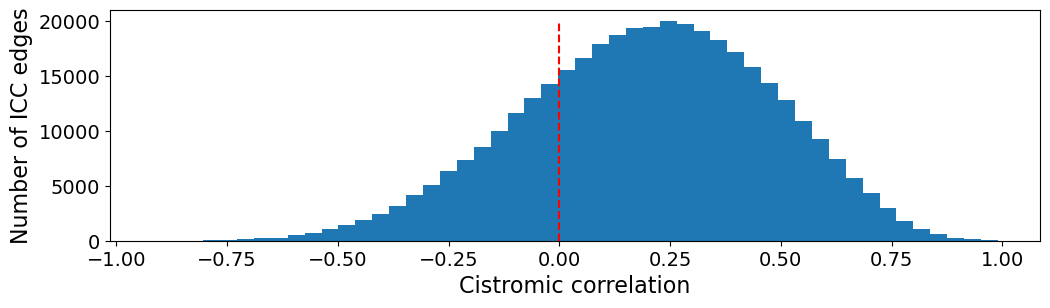

In [28]:
# Distribution of regulatory correlations
plt.figure(figsize=(12,3))
plt.hist(edge_attributes_df['cistromic_corr'], bins=50)
plt.vlines(x=0, ymin=0, ymax=20000, color='red', linestyle='dashed')
plt.xlabel('Cistromic correlation', fontsize = 16)
plt.ylabel('Number of ICC edges', fontsize = 16)
plt.xticks(fontsize = 14)
plt.yticks(fontsize = 14)
plt.show()

In [92]:
# Activity
edge_attributes_df.loc[:, 'activity'] = edge_attributes_df.apply(
    lambda row: row['activity_region1']+row['activity_region2'], axis=1
).astype(int)

# Graph of LAS contacts

## Build the graph

In [93]:
import networkx as nx

# Create network from edge list
corr_threshold = 0
unthresholded_edge_attributes_df = edge_attributes_df.copy()
thresholded_edge_attributes_df = edge_attributes_df.copy()
thresholded_edge_attributes_df = thresholded_edge_attributes_df[
    thresholded_edge_attributes_df['cistromic_corr']>corr_threshold
].copy()
G = nx.from_pandas_edgelist(
    thresholded_edge_attributes_df, 
    source='las_interacting_region1', 
    target='las_interacting_region2',
    edge_attr=thresholded_edge_attributes_df.columns.tolist()[2:]
)
print(G)
print(f'Number of edges without correlation thresholding = {unthresholded_edge_attributes_df.shape[0]}')

Graph with 4614 nodes and 285959 edges
Number of edges without correlation thresholding = 381860


In [94]:
# Add node attributes
for attribute in node_attributes_df.columns.tolist()[1:]:
    attribute_dict = {
        node_attributes_df.loc[idx, 'las_interacting_region']: node_attributes_df.loc[idx, attribute]
        for idx in node_attributes_df.index
    }
    nx.set_node_attributes(G, attribute_dict, name=attribute)

In [61]:
# Restrict to nodes and edges after cistromic correlation thresholding
edge_attributes_df = thresholded_edge_attributes_df.copy()
ls1 = edge_attributes_df['las_interacting_region1'].values.tolist()
ls2 = edge_attributes_df['las_interacting_region2'].values.tolist()
ls = np.unique(ls1+ls2)
node_attributes_df = node_attributes_df[node_attributes_df['las_interacting_region'].isin(ls)]

## Graph analysis: nodes

### Load controls

In [32]:
nonlas_node_attributes_df = pd.read_csv('../data/figure2/las_network_pixel_level/random_thresholded_node_attributes.csv', header=0, index_col=0)
nonlas_edge_attributes_df = pd.read_csv('../data/figure2/las_network_pixel_level/random_thresholded_edge_attributes_df.csv', header=0, index_col=0)

# Restrict to nodes and edges after cistromic correlation thresholding
nonlas_edge_attributes_df = nonlas_edge_attributes_df[nonlas_edge_attributes_df['cistromic_corr']>0]
ls1 = nonlas_edge_attributes_df['las_interacting_region1'].values.tolist()
ls2 = nonlas_edge_attributes_df['las_interacting_region2'].values.tolist()
ls = np.unique(ls1+ls2)
nonlas_node_attributes_df = nonlas_node_attributes_df[nonlas_node_attributes_df['las_interacting_region'].isin(ls)]

### Fig S8a

/home/dpaysan/projects/concrna/env/concrna/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/dpaysan/projects/concrna/env/concrna/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/dpaysan/projects/concrna/env/concrna/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/dpaysan/projects/concrna/env/concrna/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecat

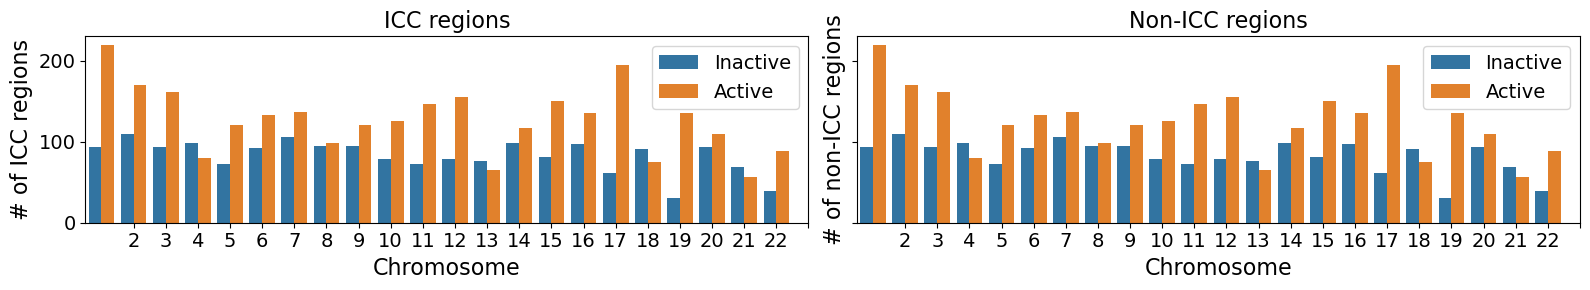

In [33]:
# Map activity numeric values to strings
activity_map = {0: "Inactive", 1: "Active"}

# ICC regions
df = node_attributes_df.groupby(['chrom', 'activity']).size().to_frame('n_regions').reset_index()
df['chrom'] = df['chrom'].str.strip('chr').astype(int)
df['activity'] = df['activity'].map(activity_map)  # <- map here

# non-ICC regions
df_non = nonlas_node_attributes_df.groupby(['chrom', 'activity']).size().to_frame('n_regions').reset_index()
df_non['chrom'] = df_non['chrom'].str.strip('chr').astype(int)
df_non['activity'] = df_non['activity'].map(activity_map)  # <- map here


# Number of interacting region
fig, axs = plt.subplots(1, 2, figsize=(16, 3), sharex=True, sharey=True)

ax = axs[0]
sns.barplot(
    data=df,
    x='chrom',
    y='n_regions',
    hue='activity',
    ax=ax
)
ax.set_xticks(np.arange(1, df['chrom'].max()+1))
ax.set_xlabel('Chromosome', fontsize = 16)
ax.set_ylabel('# of ICC regions', fontsize = 16)
ax.set_title('ICC regions', fontsize = 16)
ax.tick_params(axis='x', labelsize=14)
ax.tick_params(axis='y', labelsize=14)
ax.legend(title='', fontsize = 14)


ax = axs[1]
sns.barplot(
    data=df,
    x='chrom',
    y='n_regions',
    hue='activity',
    ax=ax
)
ax.set_xticks(np.arange(1, df['chrom'].max()+1))
ax.set_xlabel('Chromosome', fontsize = 16)
ax.set_ylabel('# of non-ICC regions', fontsize = 16)
ax.set_title('Non-ICC regions', fontsize = 16)
ax.tick_params(axis='x', labelsize=14)
ax.tick_params(axis='y', labelsize=14)
ax.legend(title='', fontsize = 14)

plt.tight_layout()
plt.show()

### Fig S8b

/home/dpaysan/projects/concrna/env/concrna/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/dpaysan/projects/concrna/env/concrna/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/dpaysan/projects/concrna/env/concrna/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/dpaysan/projects/concrna/env/concrna/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecat

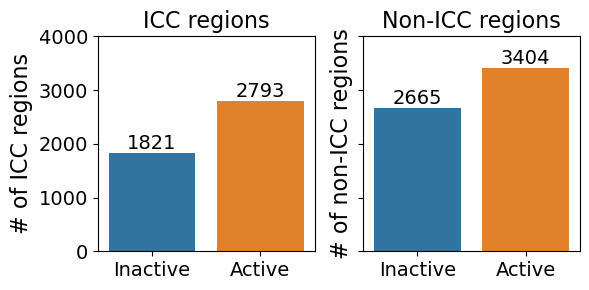

In [34]:
# Map activity numeric values to strings
activity_map = {0: "Inactive", 1: "Active"}

# Determine max for ordering bars
m1 = node_attributes_df['activity'].max()
m2 = nonlas_node_attributes_df['activity'].max()
m = max([m1, m2])

# Plot number of active vs. inactive nodes
fig, axs = plt.subplots(1, 2, figsize=(6, 3), sharex=True, sharey=True)

# ICC regions
ax = axs[0]
df = node_attributes_df.groupby('activity').size().to_frame('n_regions').reset_index()
df['activity'] = df['activity'].map(activity_map)  # map numbers to labels
sns.barplot(
    data=df,
    x='activity',
    y='n_regions',
    ax=ax,
    order=["Inactive", "Active"]  # ensure order
)
ax.bar_label(ax.containers[-1], fmt='%d', label_type='edge' , fontsize = 14)
ax.set_xlabel(None, fontsize=16)
ax.set_ylabel('# of ICC regions', fontsize=16)
ax.set_title('ICC regions', fontsize=16)
ax.tick_params(axis='x', labelsize=14)
ax.tick_params(axis='y', labelsize=14)

# non-ICC regions
ax = axs[1]
df = nonlas_node_attributes_df.groupby('activity').size().to_frame('n_regions').reset_index()
df['activity'] = df['activity'].map(activity_map)
sns.barplot(
    data=df,
    x='activity',
    y='n_regions',
    ax=ax,
    order=["Inactive", "Active"]
)
ax.bar_label(ax.containers[-1], fmt='%d', label_type='edge', fontsize = 14)
ax.set_xlabel(None, fontsize=16)
ax.set_ylabel('# of non-ICC regions', fontsize=16)
ax.set_title('Non-ICC regions', fontsize=16)
ax.tick_params(axis='x', labelsize=14)
ax.tick_params(axis='y', labelsize=14)

plt.ylim((0, 4000))
plt.tight_layout()
plt.show()


## Fig S8c

/home/dpaysan/projects/concrna/env/concrna/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/dpaysan/projects/concrna/env/concrna/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/dpaysan/projects/concrna/env/concrna/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/dpaysan/projects/concrna/env/concrna/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecat

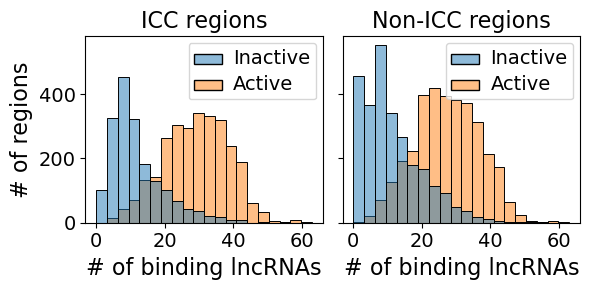

In [35]:
# Map activity numeric values to strings
activity_map = {0: "Inactive", 1: "Active"}

# Define consistent colors
activity_colors = {"Inactive": "tab:blue", "Active": "tab:orange"}

# Number of ncRNAs binding to interacting region
fig, axs = plt.subplots(1, 2, figsize=(6, 3), sharex=True, sharey=True)

# IC regions
df_ic = node_attributes_df.copy()
df_ic['activity'] = df_ic['activity'].map(activity_map)

ax = sns.histplot(
    data=df_ic,
    x='n_binding_ncrna',
    hue='activity',
    hue_order=["Inactive", "Active"],  # force order
    bins=20,
    ax=axs[0],
    palette=activity_colors,
)
axs[0].set_xlabel('# of binding lncRNAs', fontsize=16)
axs[0].set_ylabel('# of regions', fontsize=16)
axs[0].set_title('ICC regions', fontsize=16)
axs[0].tick_params(axis='x', labelsize=14)
axs[0].tick_params(axis='y', labelsize=14)
legend0 = axs[0].get_legend()
legend0.set_title(None)
plt.setp(legend0.get_texts(), fontsize=14)  # Set legend fontsize

# Non-IC regions
df_non = nonlas_node_attributes_df.copy()
df_non['activity'] = df_non['activity'].map(activity_map)

ax = sns.histplot(
    data=df_non,
    x='n_binding_ncrna',
    hue='activity',
    hue_order=["Inactive", "Active"],  # force order
    bins=20,
    ax=axs[1],
    palette=activity_colors
)
axs[1].set_xlabel('# of binding lncRNAs', fontsize=16)
axs[1].set_ylabel('# of non-ICC regions', fontsize=16)
axs[1].set_title('Non-ICC regions', fontsize=16)
axs[1].tick_params(axis='x', labelsize=14)
axs[1].tick_params(axis='y', labelsize=14)
legend1 = axs[1].get_legend()
legend1.set_title(None)
plt.setp(legend1.get_texts(), fontsize=14)  # Set legend fontsize

plt.tight_layout()
plt.show()

## Fig S8d

/home/dpaysan/projects/concrna/env/concrna/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/dpaysan/projects/concrna/env/concrna/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/dpaysan/projects/concrna/env/concrna/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/dpaysan/projects/concrna/env/concrna/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecat

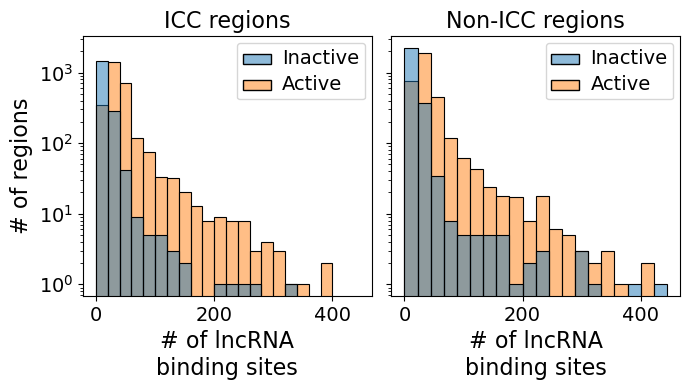

In [36]:
# Map activity numeric values to strings
activity_map = {0: "Inactive", 1: "Active"}

# Define consistent colors
activity_colors = {"Inactive": "tab:blue", "Active": "tab:orange"}

# Number of ncRNA binding sites per interacting region
fig, axs = plt.subplots(1, 2, figsize=(7, 4), sharex=True, sharey=True)

# IC regions
df_ic = node_attributes_df.copy()
df_ic['activity'] = df_ic['activity'].map(activity_map)

sns.histplot(
    data=df_ic,
    x='n_ncrna_bs', 
    hue='activity',
    hue_order=["Inactive", "Active"],
    bins=20,
    ax=axs[0],
    palette=activity_colors
)
axs[0].set_yscale('log')
axs[0].set_xlabel('# of lncRNA\nbinding sites', fontsize=16)
axs[0].set_ylabel('# of regions', fontsize=16)
axs[0].set_title('ICC regions', fontsize=16)
axs[0].tick_params(axis='x', labelsize=14)
axs[0].tick_params(axis='y', labelsize=14)
legend0 = axs[0].get_legend()
legend0.set_title(None)
plt.setp(legend0.get_texts(), fontsize=14)

# Non-IC regions
df_non = nonlas_node_attributes_df.copy()
df_non['activity'] = df_non['activity'].map(activity_map)

sns.histplot(
    data=df_non,
    x='n_ncrna_bs', 
    hue='activity',
    hue_order=["Inactive", "Active"],
    bins=20,
    ax=axs[1],
    palette=activity_colors
)
axs[1].set_yscale('log')
axs[1].set_xlabel('# of lncRNA\nbinding sites', fontsize=16)
axs[1].set_ylabel('# of non-ICC regions', fontsize=16)
axs[1].set_title('Non-ICC regions', fontsize=16)
axs[1].tick_params(axis='x', labelsize=14)
axs[1].tick_params(axis='y', labelsize=14)
legend1 = axs[1].get_legend()
legend1.set_title(None)
plt.setp(legend1.get_texts(), fontsize=14)

plt.tight_layout()

plt.show()

## Fig S8e

/home/dpaysan/projects/concrna/env/concrna/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/dpaysan/projects/concrna/env/concrna/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/dpaysan/projects/concrna/env/concrna/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/dpaysan/projects/concrna/env/concrna/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecat

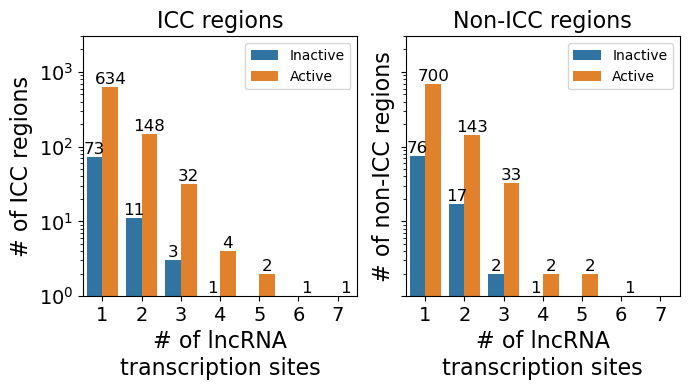

In [37]:
# Map activity numeric values to strings
activity_map = {0: "Inactive", 1: "Active"}

# Define consistent colors
activity_colors = {"Inactive": "tab:blue", "Active": "tab:orange"}

# Number of ncRNA transcription sites per interacting region
fig, axs = plt.subplots(1, 2, figsize=(7, 4), sharex=True, sharey=True)

# Calculate max for consistent x-axis
df_temp = node_attributes_df.groupby(['n_ncrna_gene', 'activity']).size().to_frame('n_regions').reset_index(drop=False)
m1 = df_temp['n_ncrna_gene'].max()
df_temp = nonlas_node_attributes_df.groupby(['n_ncrna_gene', 'activity']).size().to_frame('n_regions').reset_index(drop=False)
m2 = df_temp['n_ncrna_gene'].max()
m = max([m1, m2])

# IC regions
ax = axs[0]
df = node_attributes_df.copy()
df['activity'] = df['activity'].map(activity_map)
df = df.groupby(['n_ncrna_gene', 'activity']).size().to_frame('n_regions').reset_index(drop=False)
df = df[df['n_ncrna_gene'] > 0]

sns.barplot(
    data=df,
    x='n_ncrna_gene',
    y='n_regions',
    hue='activity',
    hue_order=["Inactive", "Active"],
    ax=ax,
    order=np.arange(1, m+1, 1),
    palette=activity_colors
)
legend0 = ax.get_legend()
legend0.set_title(None)
plt.setp(legend0.get_texts(), fontsize=15)
sns.move_legend(ax, "upper right")

for container in ax.containers:
    ax.bar_label(container, fmt='%d', label_type='edge', fontsize=12, color='black')

ax.set_yscale('log')
ax.set_xlabel('# of lncRNA\ntranscription sites', fontsize=16)
ax.set_ylabel('# of ICC regions', fontsize=16)
ax.set_title('ICC regions', fontsize=16)
ax.tick_params(axis='x', labelsize=14)
ax.tick_params(axis='y', labelsize=14)

# Non-IC regions
ax = axs[1]
df = nonlas_node_attributes_df.copy()
df['activity'] = df['activity'].map(activity_map)
df = df.groupby(['n_ncrna_gene', 'activity']).size().to_frame('n_regions').reset_index(drop=False)
df = df[df['n_ncrna_gene'] > 0]

sns.barplot(
    data=df,
    x='n_ncrna_gene',
    y='n_regions',
    hue='activity',
    hue_order=["Inactive", "Active"],
    ax=ax,
    order=np.arange(1, m+1, 1),
    palette=activity_colors
)
legend1 = ax.get_legend()
legend1.set_title(None)
plt.setp(legend1.get_texts(), fontsize=15)
sns.move_legend(ax, "upper right")

for container in ax.containers:
    ax.bar_label(container, fmt='%d', label_type='edge', fontsize=12, color='black')

ax.set_yscale('log')
ax.set_xlabel('# of lncRNA\ntranscription sites', fontsize=16)
ax.set_ylabel('# of non-ICC regions', fontsize=16)
ax.set_title('Non-ICC regions', fontsize=16)
ax.tick_params(axis='x', labelsize=14)
ax.tick_params(axis='y', labelsize=14)

plt.ylim((1, 3000))
plt.tight_layout()

plt.show()

## Graph analysis: edges

### Fig S9d

/home/dpaysan/projects/concrna/env/concrna/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/dpaysan/projects/concrna/env/concrna/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/dpaysan/projects/concrna/env/concrna/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


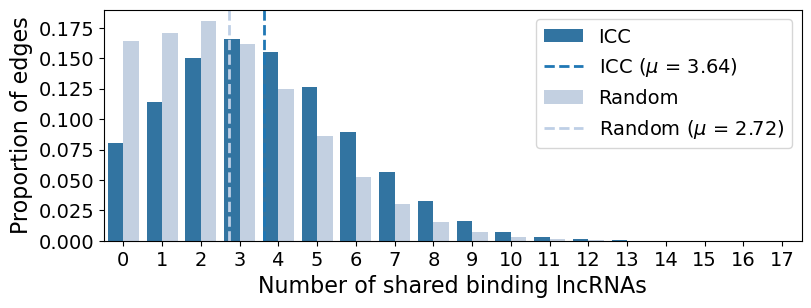

In [38]:
mean_value_las = edge_attributes_df['n_shared_bindingncrna'].mean()
mean_value_nonlas = nonlas_edge_attributes_df['n_shared_bindingncrna'].mean()

# Combine both plots
df_las = edge_attributes_df.groupby('n_shared_bindingncrna').size().to_frame('n_las')
df_las = df_las.reset_index(drop=False)
df_las.loc[:, 'prop_las'] = df_las['n_las'].apply(lambda x: x/edge_attributes_df.shape[0])
df_las.loc[:, 'Edges'] = 'ICC'
df_nonlas = nonlas_edge_attributes_df.groupby('n_shared_bindingncrna').size().to_frame('n_las')
df_nonlas = df_nonlas.reset_index(drop=False)
df_nonlas.loc[:, 'prop_las'] = df_nonlas['n_las'].apply(lambda x: x/nonlas_edge_attributes_df.shape[0])
df_nonlas.loc[:, 'Edges'] = 'Random'
df = pd.concat([df_las, df_nonlas], axis=0)
m = df['n_shared_bindingncrna'].max()

plt.figure(figsize=(9,3))
ax = sns.barplot(
    data=df,
    x='n_shared_bindingncrna',
    y='prop_las',
    hue='Edges',
    palette=['#1f77b4', '#becfe6'],
    order=np.arange(0, m+1, 1)
)
ax.axvline(
    mean_value_las, color='#1f77b4', linestyle='--', linewidth=2, label=f'ICC ($\mu$ = {mean_value_las:.2f})'
)
ax.axvline(
    mean_value_nonlas, color='#becfe6', linestyle='--', linewidth=2, label=f'Random ($\mu$ = {mean_value_nonlas:.2f})'
)
handles, labels = plt.gca().get_legend_handles_labels()
order = [2,0,3,1]
plt.legend([handles[idx] for idx in order],[labels[idx] for idx in order], fontsize = 14)
plt.xlabel('Number of shared binding lncRNAs', fontsize = 16)
plt.ylabel('Proportion of edges', fontsize = 16)
plt.xticks(fontsize = 14)
plt.yticks(fontsize = 14)

plt.show()

## Fig 2e

/home/dpaysan/projects/concrna/env/concrna/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/dpaysan/projects/concrna/env/concrna/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/dpaysan/projects/concrna/env/concrna/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


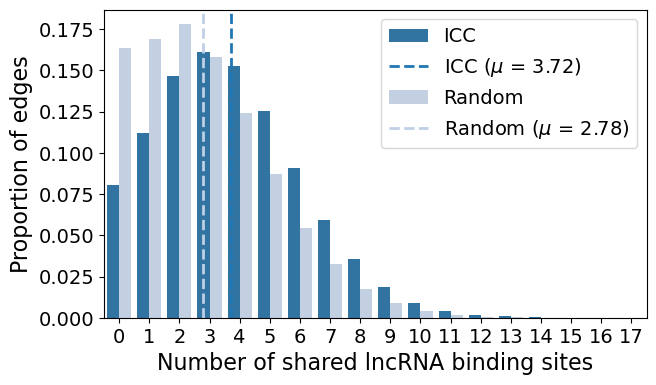

In [39]:
mean_value_las = edge_attributes_df['n_shared_ncrna_bs'].mean()
mean_value_nonlas = nonlas_edge_attributes_df['n_shared_ncrna_bs'].mean()

# Combine both plots
df_las = edge_attributes_df.groupby('n_shared_ncrna_bs').size().to_frame('n_las')
df_las = df_las.reset_index(drop=False)
df_las.loc[:, 'prop_las'] = df_las['n_las'].apply(lambda x: x/edge_attributes_df.shape[0])
df_las.loc[:, 'Edges'] = 'ICC'
df_nonlas = nonlas_edge_attributes_df.groupby('n_shared_ncrna_bs').size().to_frame('n_las')
df_nonlas = df_nonlas.reset_index(drop=False)
df_nonlas.loc[:, 'prop_las'] = df_nonlas['n_las'].apply(lambda x: x/nonlas_edge_attributes_df.shape[0])
df_nonlas.loc[:, 'Edges'] = 'Random'
df = pd.concat([df_las, df_nonlas], axis=0)
m = df['n_shared_ncrna_bs'].max()

plt.figure(figsize=(7,4))
ax = sns.barplot(
    data=df,
    x='n_shared_ncrna_bs',
    y='prop_las',
    hue='Edges',
    palette=['#1f77b4', '#becfe6'],
    order=np.arange(0, m+1, 1)
)
ax.axvline(
    mean_value_las, color='#1f77b4', linestyle='--', linewidth=2, label=f'ICC ($\mu$ = {mean_value_las:.2f})'
)
ax.axvline(
    mean_value_nonlas, color='#becfe6', linestyle='--', linewidth=2, label=f'Random ($\mu$ = {mean_value_nonlas:.2f})'
)
handles, labels = plt.gca().get_legend_handles_labels()
order = [2,0,3,1]
plt.legend([handles[idx] for idx in order],[labels[idx] for idx in order], fontsize = 14)
plt.xlabel('Number of shared lncRNA binding sites', fontsize = 16)
plt.ylabel('Proportion of edges', fontsize = 16)

plt.xticks(fontsize = 14)
plt.yticks(fontsize = 14)

plt.show()

### Fig 2f

/home/dpaysan/projects/concrna/env/concrna/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/dpaysan/projects/concrna/env/concrna/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/dpaysan/projects/concrna/env/concrna/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


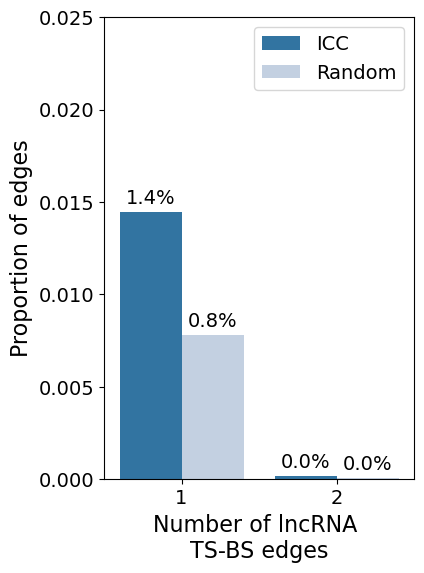

In [44]:
df_las = edge_attributes_df.groupby('n_coloc_ts_bs').size().to_frame('n_las').reset_index(drop=False)
df_las.loc[:, 'prop_las'] = df_las['n_las'].apply(lambda x: x/edge_attributes_df.shape[0])
m1 = df_las['n_coloc_ts_bs'].max()
df_nonlas = nonlas_edge_attributes_df.groupby('n_coloc_ts_bs').size().to_frame('n_las').reset_index(drop=False)
df_nonlas.loc[:, 'prop_las'] = df_nonlas['n_las'].apply(lambda x: x/edge_attributes_df.shape[0])
m2 = df_nonlas['n_coloc_ts_bs'].max()
m = max([m1, m2])

# Combine both plots
df_las.loc[:, 'Edges'] = 'ICC'
df_nonlas.loc[:, 'Edges'] = 'Random'
df = pd.concat([df_las, df_nonlas], axis=0)
plt.figure(figsize=(4,6))
ax = sns.barplot(
    data=df,
    x='n_coloc_ts_bs',
    y='prop_las',
    hue='Edges',
    palette=['#1f77b4', '#becfe6'],
    order=np.arange(1, m+1, 1)
)
for p in ax.patches:
    ax.annotate(f'{100*p.get_height():.1f}%', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 10), textcoords='offset points', fontsize = 14)
plt.ylim((0, 0.025))
plt.xlabel('Number of lncRNA \nTS-BS edges', fontsize = 16)
plt.ylabel('Proportion of edges', fontsize = 16)
plt.xticks(fontsize = 14)
plt.yticks(fontsize = 14)
ax.legend(fontsize = 14)


plt.show()


### Fig S9b

/home/dpaysan/projects/concrna/env/concrna/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/dpaysan/projects/concrna/env/concrna/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/dpaysan/projects/concrna/env/concrna/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/dpaysan/projects/concrna/env/concrna/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecat

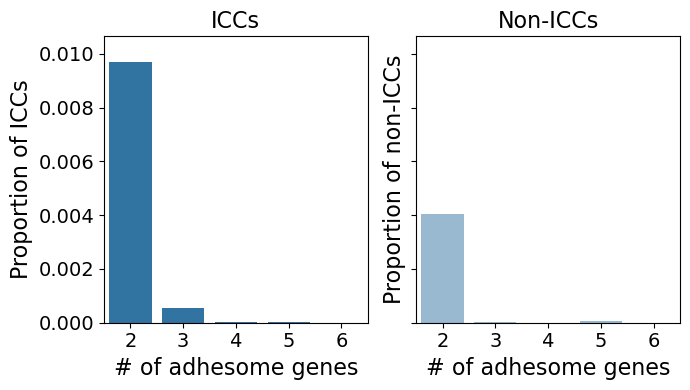

In [45]:
# Interchromosomal colocalization of geneset genes

gs = 'ADHESOME'

fig, axs = plt.subplots(1, 2, figsize=(7, 4), sharex=True, sharey=True)

df = edge_attributes_df.groupby(f'n_coloc_{gs}').size().to_frame('n_las').reset_index(drop=False)
m1 = df[f'n_coloc_{gs}'].max()
df = nonlas_edge_attributes_df.groupby(f'n_coloc_{gs}').size().to_frame('n_las').reset_index(drop=False)
m2 = df[f'n_coloc_{gs}'].max()
m = max([m1, m2])

ax = axs[0]
df = edge_attributes_df.groupby(f'n_coloc_{gs}').size().to_frame('n_las').reset_index(drop=False)
df.loc[:, 'prop_las'] = df['n_las'].apply(lambda x: x/edge_attributes_df.shape[0])
df = df[df[f'n_coloc_{gs}']>1]
h0 = df['prop_las'].max()
sns.barplot(
    data=df.loc[1:,:],
    x=f'n_coloc_{gs}',
    y='prop_las',
    ax=ax,
    color='#1f77b4',
    order=np.arange(2, m+1, 1)
)
# ax.set_yscale('log')
#     ax.bar_label(ax.containers[-1], fmt='%f', label_type='edge')
ax.set_xlabel(f'# of adhesome genes', fontsize = 16)
ax.set_ylabel('Proportion of ICCs', fontsize = 16)
ax.set_title('ICCs', fontsize = 16)
ax.tick_params(axis='x', labelsize=14,)  # x-axis ticks
ax.tick_params(axis='y', labelsize=14)              # y-axis ticks

ax = axs[1]
df = nonlas_edge_attributes_df.groupby(f'n_coloc_{gs}').size().to_frame('n_las').reset_index(drop=False)
df.loc[:, 'prop_las'] = df['n_las'].apply(lambda x: x/nonlas_edge_attributes_df.shape[0])
df = df[df[f'n_coloc_{gs}']>1]
h1 = df['prop_las'].max()
sns.barplot(
    data=df.loc[1:,:],
    x=f'n_coloc_{gs}',
    y='prop_las',
    alpha=0.5,
    ax=ax,
    color='#1f77b4',
    order=np.arange(2, m+1, 1)
)
#     ax.bar_label(ax.containers[-1], fmt='%f', label_type='edge')
# ax.set_yscale('log')
ax.set_xlabel(f'# of adhesome genes', fontsize = 16)
ax.set_ylabel('Proportion of non-ICCs', fontsize = 16)
ax.set_title('Non-ICCs', fontsize = 16)
ax.tick_params(axis='x', labelsize=14,)  # x-axis ticks
ax.tick_params(axis='y', labelsize=14)              # y-axis ticks

h = max([h0, h1])
plt.ylim((0, h*1.1))
plt.tight_layout()

plt.show()

### Fig S9c

/home/dpaysan/projects/concrna/env/concrna/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/dpaysan/projects/concrna/env/concrna/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/dpaysan/projects/concrna/env/concrna/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/dpaysan/projects/concrna/env/concrna/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecat

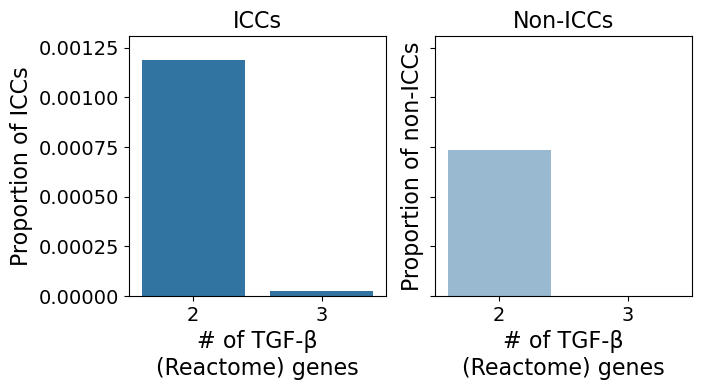

In [46]:
# Interchromosomal colocalization of geneset genes

gs = 'REACTOME_TGF_BETA'

fig, axs = plt.subplots(1, 2, figsize=(7, 4), sharex=True, sharey=True)

df = edge_attributes_df.groupby(f'n_coloc_{gs}').size().to_frame('n_las').reset_index(drop=False)
m1 = df[f'n_coloc_{gs}'].max()
df = nonlas_edge_attributes_df.groupby(f'n_coloc_{gs}').size().to_frame('n_las').reset_index(drop=False)
m2 = df[f'n_coloc_{gs}'].max()
m = max([m1, m2])

ax = axs[0]
df = edge_attributes_df.groupby(f'n_coloc_{gs}').size().to_frame('n_las').reset_index(drop=False)
df.loc[:, 'prop_las'] = df['n_las'].apply(lambda x: x/edge_attributes_df.shape[0])
df = df[df[f'n_coloc_{gs}']>1]
h0 = df['prop_las'].max()
sns.barplot(
    data=df.loc[1:,:],
    x=f'n_coloc_{gs}',
    y='prop_las',
    ax=ax,
    color='#1f77b4',
    order=np.arange(2, m+1, 1)
)
# ax.set_yscale('log')
#     ax.bar_label(ax.containers[-1], fmt='%f', label_type='edge')
ax.set_xlabel(f'# of TGF-β\n(Reactome) genes', fontsize = 16)
ax.set_ylabel('Proportion of ICCs', fontsize = 16)
ax.set_title('ICCs', fontsize = 16)
ax.tick_params(axis='x', labelsize=14,)  # x-axis ticks
ax.tick_params(axis='y', labelsize=14)              # y-axis ticks

ax = axs[1]
df = nonlas_edge_attributes_df.groupby(f'n_coloc_{gs}').size().to_frame('n_las').reset_index(drop=False)
df.loc[:, 'prop_las'] = df['n_las'].apply(lambda x: x/nonlas_edge_attributes_df.shape[0])
df = df[df[f'n_coloc_{gs}']>1]
h1 = df['prop_las'].max()
sns.barplot(
    data=df.loc[1:,:],
    x=f'n_coloc_{gs}',
    y='prop_las',
    alpha=0.5,
    ax=ax,
    color='#1f77b4',
    order=np.arange(2, m+1, 1)
)
#     ax.bar_label(ax.containers[-1], fmt='%f', label_type='edge')
# ax.set_yscale('log')
ax.set_xlabel(f'# of TGF-β\n(Reactome) genes', fontsize = 16)
ax.set_ylabel('Proportion of non-ICCs', fontsize = 16)
ax.set_title('Non-ICCs', fontsize = 16)
ax.tick_params(axis='x', labelsize=14,)  # x-axis ticks
ax.tick_params(axis='y', labelsize=14)              # y-axis ticks

h = max([h0, h1])
plt.ylim((0, h*1.1))
plt.tight_layout()

plt.show()

### Fig 2g

/home/dpaysan/projects/concrna/env/concrna/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/dpaysan/projects/concrna/env/concrna/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/dpaysan/projects/concrna/env/concrna/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/dpaysan/projects/concrna/env/concrna/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecat

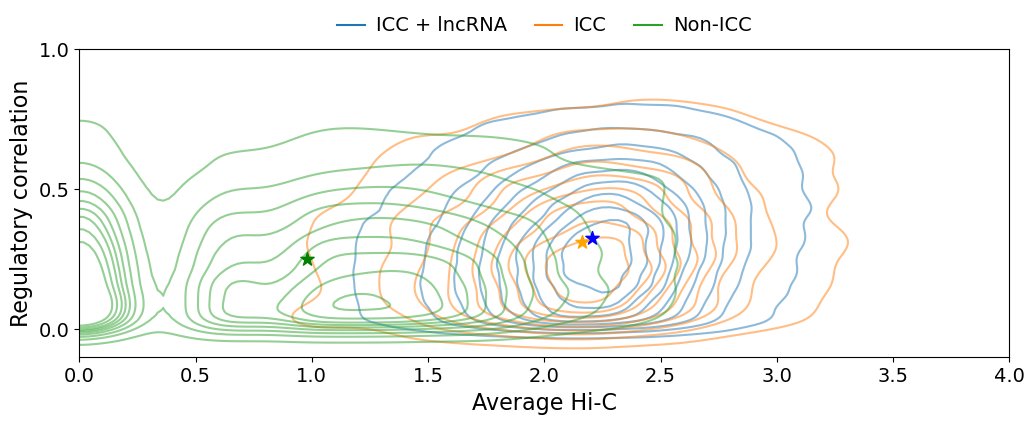

In [50]:
# Activity pixels in LAS+ncRNA, LAS, and non LAS
prop = 1
df1 = edge_attributes_df.copy()
df1 = df1[df1['activity']==2]
df1 = df1[df1['n_shared_bindingncrna']>0].sample(frac=prop)
df1.loc[:, 'Type'] = 'ICC + lncRNA'
m_hic_1 = df1['avg'].mean()
m_reg_1 = df1['cistromic_corr'].mean()

df2 = edge_attributes_df.copy()
df2 = df2[df2['activity']==2]
df2 = df2[df2['n_shared_bindingncrna']==0].sample(frac=prop)
df2.loc[:, 'Type'] = 'ICC'
m_hic_2 = df2['avg'].mean()
m_reg_2 = df2['cistromic_corr'].mean()

df3 = nonlas_edge_attributes_df.copy()
df3 = df3[df3['activity']==2]
df3 = df3[df3['n_shared_bindingncrna']==0].sample(frac=prop)
df3.loc[:, 'Type'] = 'Non-ICC'
m_hic_3 = df3['avg'].mean()
m_reg_3 = df3['cistromic_corr'].mean()

df = pd.concat([df1, df2, df3], axis=0)
df = df.reset_index(drop=True)

plt.figure(figsize=(12,4))
g = sns.kdeplot(
    data=df, 
    x="avg", 
    y="cistromic_corr", 
    hue='Type',
    common_norm=False,
    clip=(-1, 8),
    levels=10,
    alpha=0.5
)
plt.scatter([m_hic_1], [m_reg_1], color='blue', marker='*', s=100, zorder=10)
plt.scatter([m_hic_2], [m_reg_2], color='orange', marker='*', s=100, zorder=10)
plt.scatter([m_hic_3], [m_reg_3], color='green', marker='*', s=100, zorder=10)
plt.xlim(0, 4)
plt.ylim(-0.1,1)
plt.yticks([0, 0.5, 1])
     # set label font size

# Move legend to top in one row
sns.move_legend(
    g,
    "upper center",
    bbox_to_anchor=(0.5, 1.15),  # move above plot
    ncol=3,                      # one row (3 groups)
    frameon=False
)

plt.xlabel('Average Hi-C', fontsize =16)
plt.ylabel('Regulatory correlation', fontsize =16)
# plt.title('Active IC edges', fontsize =16)
plt.xticks(fontsize = 14)
plt.yticks(fontsize = 14)

legend = g.get_legend()          # get the legend object
legend.set_title('')             # remove the legend title
for text in legend.get_texts():  # loop over the labels
    text.set_fontsize(14)   

plt.show()

In [52]:
import scipy.stats as ss

# WRS tests for the x and y distributions above

stat, pval = ss.ranksums(
    x=df1['avg'].values,
    y=df2['avg'].values
)
print(f'Hi-C WRS stat = {stat} \nWRS pval = {pval}')

stat, pval = ss.ranksums(
    x=df1['cistromic_corr'].values,
    y=df2['cistromic_corr'].values
)
print(f'Regulatory WRS stat = {stat} \nWRS pval = {pval}')

Hi-C WRS stat = 7.950049266341612 
WRS pval = 1.8643735763449373e-15
Regulatory WRS stat = 7.255450250024078 
WRS pval = 4.0032790180543475e-13


### Fig S9e

/home/dpaysan/projects/concrna/env/concrna/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/dpaysan/projects/concrna/env/concrna/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/dpaysan/projects/concrna/env/concrna/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/dpaysan/projects/concrna/env/concrna/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecat

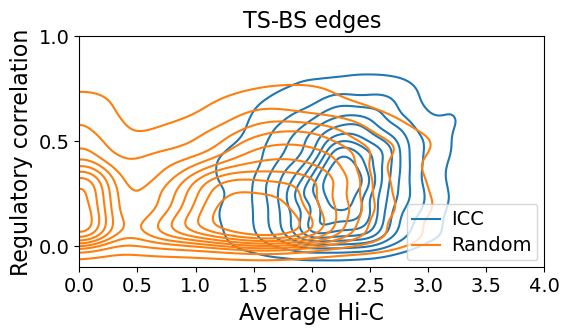

In [53]:
# TS-BS colocalization pixels
prop = 1
plt.figure(figsize=(6,3))
df1 = edge_attributes_df.copy()
df1 = df1[df1['n_coloc_ts_bs']>0].sample(frac=prop)
df1.loc[:, 'Type'] = 'ICC' 
df2 = nonlas_edge_attributes_df.copy()
df2 = df2[df2['n_coloc_ts_bs']>0].sample(frac=prop)
df2.loc[:, 'Type'] = 'Random'
df = pd.concat([df1, df2], axis=0)
df = df.reset_index(drop=True)
g = sns.kdeplot(
    data=df, 
    x="avg", 
    y="cistromic_corr", 
    hue='Type',
    common_norm=False,
    clip=(-1, 4),
)
plt.xlim(0, 4)
plt.ylim(-0.1,1)
plt.yticks([0, 0.5, 1])
g.get_legend().set_title('')
sns.move_legend(g, "lower right")
plt.xlabel('Average Hi-C', fontsize = 16)
plt.ylabel('Regulatory correlation', fontsize = 16)
plt.title('TS-BS edges', fontsize = 16)
plt.xticks(fontsize = 14)
plt.yticks(fontsize = 14)

legend = g.get_legend()          # get the legend object
legend.set_title('')             # remove the legend title
for text in legend.get_texts():  # loop over the labels
    text.set_fontsize(14)  

plt.show()

### Fig S9f

/home/dpaysan/projects/concrna/env/concrna/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/dpaysan/projects/concrna/env/concrna/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/dpaysan/projects/concrna/env/concrna/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/dpaysan/projects/concrna/env/concrna/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecat

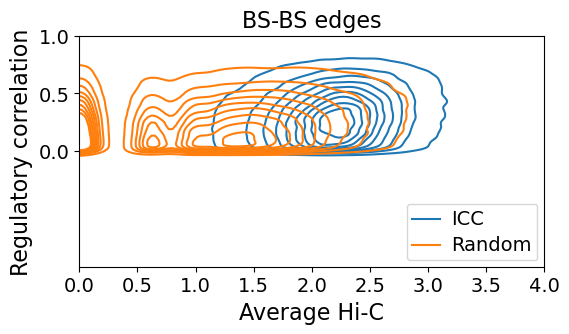

In [54]:
# BS-BS colocalization pixels
prop = 1
plt.figure(figsize=(6,3))
df1 = edge_attributes_df.copy()
df1 = df1[df1['n_shared_ncrna_bs']>0].sample(frac=prop)
df1.loc[:, 'Type'] = 'ICC' 
df2 = nonlas_edge_attributes_df.copy()
df2 = df2[df2['n_shared_ncrna_bs']>0].sample(frac=prop)
df2.loc[:, 'Type'] = 'Random'
df = pd.concat([df1, df2], axis=0)
df = df.reset_index(drop=True)
g = sns.kdeplot(
    data=df, 
    x="avg", 
    y="cistromic_corr", 
    hue='Type',
    common_norm=False,
    clip=(-1, 8),
)
plt.xlim(0, 4)
plt.ylim(-1,1)
plt.yticks([0, 0.5, 1])
g.get_legend().set_title('')
sns.move_legend(g, "lower right")
plt.xlabel('Average Hi-C', fontsize = 16)
plt.ylabel('Regulatory correlation', fontsize = 16)
plt.title('BS-BS edges', fontsize = 16)

plt.xticks(fontsize = 14)
plt.yticks(fontsize = 14)

legend = g.get_legend()          # get the legend object
legend.set_title('')             # remove the legend title
for text in legend.get_texts():  # loop over the labels
    text.set_fontsize(14)  
plt.show()

### Fig S9a

/home/dpaysan/projects/concrna/env/concrna/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/dpaysan/projects/concrna/env/concrna/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/dpaysan/projects/concrna/env/concrna/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/dpaysan/projects/concrna/env/concrna/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecat

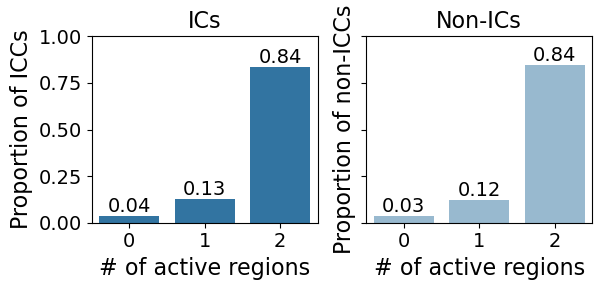

In [55]:
# Activity of edges
fig, axs = plt.subplots(1, 2, figsize=(6, 3), sharex=True, sharey=True)

df = edge_attributes_df.groupby('activity').size().to_frame('n_las').reset_index(drop=False)
m1 = df['activity'].max()
df = nonlas_edge_attributes_df.groupby('activity').size().to_frame('n_las').reset_index(drop=False)
m2 = df['activity'].max()
m = max([m1, m2])

ax = axs[0]
df = edge_attributes_df.groupby('activity').size().to_frame('n_las').reset_index(drop=False)
df.loc[:, 'prop_las'] = df['n_las'].apply(lambda x: x/edge_attributes_df.shape[0])
sns.barplot(
    data=df,
    x='activity',
    y='prop_las',
    ax=ax,
    color='#1f77b4',
    order=np.arange(0, m+1, 1)
)
ax.bar_label(ax.containers[-1], fmt='%.2f', label_type='edge', fontsize = 14)
ax.set_xlabel('# of active regions', fontsize = 16)
ax.set_ylabel('Proportion of ICCs', fontsize = 16)
ax.set_title('ICs', fontsize = 16)
ax.tick_params(axis='x', labelsize=14)  # x-axis ticks
ax.tick_params(axis='y', labelsize=14)              # y-axis ticks

ax = axs[1]
df = nonlas_edge_attributes_df.groupby('activity').size().to_frame('n_las').reset_index(drop=False)
df.loc[:, 'prop_las'] = df['n_las'].apply(lambda x: x/nonlas_edge_attributes_df.shape[0])
sns.barplot(
    data=df,
    x='activity',
    y='prop_las',
    alpha=0.5,
    ax=ax,
    color='#1f77b4',
    order=np.arange(0, m+1, 1)
)
ax.bar_label(ax.containers[-1], fmt='%.2f', label_type='edge', fontsize = 14)
ax.set_xlabel('# of active regions', fontsize = 16)
ax.set_ylabel('Proportion of non-ICCs', fontsize = 16)
ax.set_title('Non-ICs', fontsize = 16)
ax.tick_params(axis='x', labelsize=14)  # x-axis ticks
ax.tick_params(axis='y', labelsize=14)              # y-axis ticks


plt.ylim((0, 1))
plt.tight_layout()

plt.show()

# Analyzing subnetworks induced by lncRNAs

In [95]:
# General network properties
print('Number of nodes', len(G.nodes))
print('Number of edges', len(G.edges))
print('Average degree', sum(dict(G.degree).values()) / len(G.nodes))

Number of nodes 4614
Number of edges 285959
Average degree 123.95275249241439


## Network of nodes sharing binding sites of lncRNAs

In [96]:
# Node conditions
node_condition = lambda node: (
(G.nodes[node]['activity'] == 1) and \
(G.nodes[node]['n_binding_ncrna'] > 0)
)
nodes_to_keep = [node for node in G.nodes if node_condition(node)]

### Fig S12a

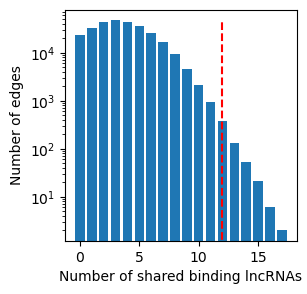

In [97]:
# Edge conditions
edge_condition = lambda edge: ( \
(G[edge[0]][edge[1]]['activity'] == 2) and \
(G[edge[0]][edge[1]]['avg'] > 2) and \
(G[edge[0]][edge[1]]['n_shared_bindingncrna'] >= 12) and \
(G[edge[0]][edge[1]]['cistromic_corr'] > 0.5)
)
edges_to_keep = [edge for edge in G.edges if edge_condition(edge)]

n_shared_bindingncrna_list = [e[2]['n_shared_bindingncrna'] for e in G.edges(data=True)]
x, h = np.unique(n_shared_bindingncrna_list, return_counts=True)
plt.figure(figsize=(3,3))
plt.bar(
    x=x,
    height=h
)
plt.vlines(x=12, ymin=0, ymax=max(h), color='red', linestyle='dashed')
plt.yscale('log')
plt.xlabel('Number of shared binding lncRNAs')
plt.ylabel('Number of edges')
plt.show()

In [98]:
# Create subnetwork
subG = G.subgraph(nodes_to_keep).copy()
subG = subG.edge_subgraph(edges_to_keep).copy()
isolated_nodes = list(nx.isolates(subG))
subG.remove_nodes_from(isolated_nodes)
print(subG)

Graph with 124 nodes and 129 edges


In [99]:
# Add PPI interactions attribute
attribute = 'ppi_interactions'
ppi_interactions_attribute = {}
for source, target, att in subG.edges(data=True):
    loc1 = source.split('_')[1]+'_loc_'+source.split('_')[2]
    loc2 = target.split('_')[1]+'_loc_'+target.split('_')[2]
    genes1 = [hgnc2ensembl[g] for g in locus2genes[loc1]]
    genes2 = [hgnc2ensembl[g] for g in locus2genes[loc2]]
    genepairs = itertools.product(genes1, genes2)
    genepairs_in_ppi = [pair for pair in genepairs if (pair in string_graph.edges())]
    genepairs_in_ppi = [(ensembl2hgnc[pair[0]], ensembl2hgnc[pair[1]]) for pair in genepairs_in_ppi]
    ppi_interactions_attribute[(source, target)] = genepairs_in_ppi
nx.set_edge_attributes(subG, ppi_interactions_attribute, attribute)

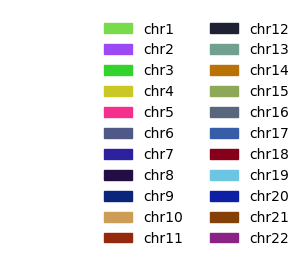

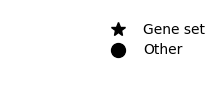

In [104]:
import random
import matplotlib.patches as mpatches
import matplotlib.lines as mlines

# Create legend for chromosomes
random.seed(4)
def generate_color():
    return '#%06x' % random.randint(0, 0xFFFFFF)
colors=[]
for i in range(1,22+1):  
    c = generate_color()
    while(c in colors):
        c = generate_color()
    colors.append(c)
node_color_dict = {f'chr{chrom}': colors[chrom - 1] for chrom in np.arange(1, 22 + 1, 1)}
legend_patches = [mpatches.Patch(color=color, label=label) for label, color in node_color_dict.items()]

fig, ax = plt.subplots(figsize=(1, 1))
ax.legend(handles=legend_patches, bbox_to_anchor=(1.05, 1), loc='upper left', ncol=2, frameon=False)
ax.axis('off')
plt.show()

# Create legend for ncRNA TS
node_shape_dict = {
    'Gene set': 'star', 
    'Other': 'dot'
}
node_shape_dict_matplotlib = {
    'Gene set': '*', 
    'Other': 'o'
}
legend_lines = [
    mlines.Line2D([0], [0], 
                  marker=shape, color='black', 
                  label=label, markersize=10, 
                  markeredgecolor='black', linestyle='None') 
    for label, shape in node_shape_dict_matplotlib.items()
]

fig, ax = plt.subplots(figsize=(1, 1))
ax.legend(handles=legend_lines, bbox_to_anchor=(1.05, 1), loc='upper left', frameon=False)
ax.axis('off')
plt.show()

### Fig S12b

In [102]:
# Display subnetwork
from pyvis.network import Network
from IPython.display import HTML, IFrame

#####################################################################################
# Node attributes
#####################################################################################

# Node labels
labels = {}
for node, node_data in subG.nodes(data=True):
    
    label = []
    for gs in aging_genesets.keys():
        label.extend([ensembl2hgnc[g] for g in node_data[f'genes_{gs}']])
    label = np.unique(label)
    if len(label)==0:
        label = ' '
    else:
        label = ','.join(label)
    labels[node] = label

# Node colors
node_colors = {
    node: node_color_dict[node_data['chrom']] for node, node_data in subG.nodes(data=True)
}
# Node shapes
node_shape_dict = {
    'Gene set': 'star', 
    'Other': 'dot'
}
node_type_dict = {}
for node, node_data in subG.nodes(data=True):
    node_type = 'Other'
    for gs in aging_genesets.keys():
        if (node_data[f'n_genes_{gs}']>0):
            node_type = 'Gene set'
    node_type_dict[node] = node_type
node_shapes = {
    node: node_shape_dict[node_type_dict[node]] for node in subG.nodes()
}
# Node titles
subG_las_loci = list(subG.nodes())
subG_loci = [loc.split('_')[1]+'_loc_'+loc.split('_')[2] for loc in subG_las_loci]
subG_genes = {
    subG_las_loci[i]: ','.join(locus2genes[subG_loci[i]]) for i in np.arange(len(subG_las_loci))
}
subG_pc_genes = {
    subG_las_loci[i]: ','.join(locus2pcgenes[subG_loci[i]]) for i in np.arange(len(subG_las_loci))
}

#####################################################################################
# Edge attributes
#####################################################################################

# Edge sizes
edge_sizes = {
    (u, v): att['n_shared_bindingncrna'] 
    for u, v, att in subG.edges(data=True)
}
# Edge colors
edge_colors = {}
for u, v, att in subG.edges(data=True):
    if (len(att['ppi_interactions'])>0):
        edge_colors[(u, v)] = 'dodgerblue'
    else:
        edge_colors[(u, v)] = 'grey'
# Edge titles
edge_titles = {
    (u, v): ', '.join(['/'.join(pair) for pair in att['ppi_interactions']]) 
    for u, v, att in subG.edges(data=True)
}

#####################################################################################
# Create and display network
#####################################################################################

# Create a Pyvis network
pyvis_graph = Network(
    height='1000px',width='95%', notebook=True, cdn_resources='in_line'
)
pyvis_graph.force_atlas_2based()

# Add nodes with labels and colors
for node, node_data in subG.nodes(data=True):
    pyvis_graph.add_node(
        node, 
        label=labels[node], 
        color=node_colors[node], 
        shape=node_shapes[node], 
        title=subG_pc_genes[node],
        font={'size': 50}
    )

# Add edges with colors and sizes
for u, v, att in subG.edges(data=True):
    pyvis_graph.add_edge(
        u, v, 
        color=edge_colors[(u,v)], 
        value=edge_sizes[(u,v)], 
        title=edge_titles[(u,v)]
    )

# pyvis_graph.toggle_physics(False)
pyvis_graph.show_buttons(['physics'])
fname = 'test.html'
pyvis_graph.show(fname)
IFrame(src=fname, width=800, height=700)

test.html


## Cluster network

### Fig S12c

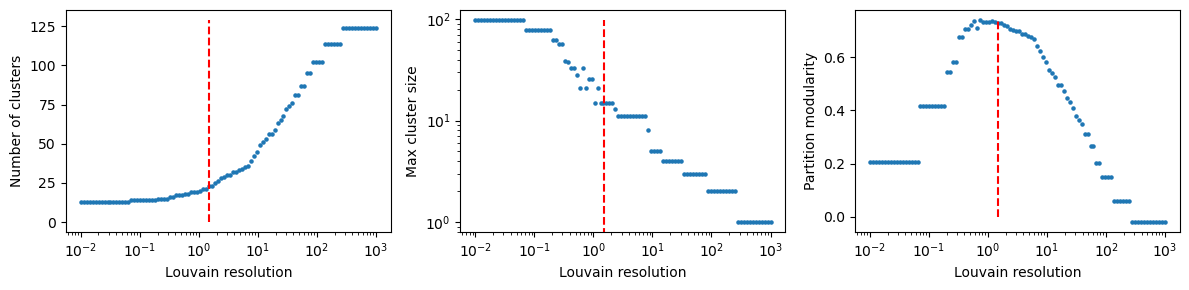

In [105]:
# Choose resolution for Louvain clustering of subnetwork
resolution_ls = np.power(10, np.linspace(-2, 3, 100))
n_clusters = []
max_clustersize_list = []
modularity_list = []
for resolution in resolution_ls:
    clusters = nx.community.louvain_communities(
        subG, 
        weight='None', # 'n_shared_bindingncrna'
        resolution=resolution, 
        threshold=1e-07, 
        seed=13
    )
    n_clusters.append(len(clusters))
    # Maximum cluster size
    max_clustersize = max([len(c) for c in clusters])
    max_clustersize_list.append(max_clustersize)
    # Modularity
    modularity = nx.community.modularity(subG, clusters, resolution=1)
    modularity_list.append(modularity)

t_louvain = 1.5

fig, axs = plt.subplots(1, 3, figsize=(12, 3), sharex=True, sharey=False)

ax = axs[0]
ax.scatter(resolution_ls, n_clusters, s=5)
ax.vlines(x=t_louvain, ymin=0, ymax=len(subG.nodes())+5, color='red', linestyle='dashed')
ax.set_xscale("log")
ax.set_xlabel("Louvain resolution")
ax.set_ylabel("Number of clusters")

ax = axs[1]
ax.scatter(resolution_ls, max_clustersize_list, s=5)
ax.vlines(
    x=t_louvain, ymin=0, ymax=max(max_clustersize_list), color="red", linestyle="dashed"
)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Louvain resolution")
ax.set_ylabel("Max cluster size")

ax = axs[2]
ax.scatter(resolution_ls, modularity_list, s=5)
ax.vlines(
    x=t_louvain, ymin=0, ymax=max(modularity_list), color="red", linestyle="dashed"
)
ax.set_xlabel("Louvain resolution")
ax.set_ylabel("Partition modularity")

plt.tight_layout()
plt.show()

In [106]:
# Cluster subnetwork
resolution = 1.5
clusters = nx.community.louvain_communities(
    subG, 
    weight='None', # 'n_shared_bindingncrna'
    resolution=resolution, 
    threshold=1e-07, 
    seed=13
)
cluster2nodes = {f'cluster_{idx}': sorted(clusters[idx]) for idx in range(len(clusters))}
node2cluster = {}
for k, v in cluster2nodes.items():
    for node in v:
        node2cluster[node] = k

### Fig S12d

In [108]:
# Display subnetwork

#####################################################################################
# Node attributes
#####################################################################################

# Node labels
labels = {}
for node, node_data in subG.nodes(data=True):
    
    label = []
    for gs in aging_genesets.keys():
        label.extend([ensembl2hgnc[g] for g in node_data[f'genes_{gs}']])
    label = np.unique(label)
    if len(label)==0:
        label = ' '
    else:
        label = ','.join(label)
    labels[node] = label

# Node colors
node_colors = {
    node: cluster_color_dict[node2cluster[node]] for node, node_data in subG.nodes(data=True)
}
# Node shapes
node_shape_dict = {
    'Gene set': 'star', 
    'Other': 'dot'
}
node_type_dict = {}
for node, node_data in subG.nodes(data=True):
    node_type = 'Other'
    for gs in aging_genesets.keys():
        if (node_data[f'n_genes_{gs}']>0):
            node_type = 'Gene set'
    node_type_dict[node] = node_type
node_shapes = {
    node: node_shape_dict[node_type_dict[node]] for node in subG.nodes()
}
# Node titles
subG_las_loci = list(subG.nodes())
subG_loci = [loc.split('_')[1]+'_loc_'+loc.split('_')[2] for loc in subG_las_loci]
subG_genes = {
    subG_las_loci[i]: ','.join(locus2genes[subG_loci[i]]) for i in np.arange(len(subG_las_loci))
}
subG_pc_genes = {
    subG_las_loci[i]: ','.join(locus2pcgenes[subG_loci[i]]) for i in np.arange(len(subG_las_loci))
}

#####################################################################################
# Edge attributes
#####################################################################################

# Edge sizes
edge_sizes = {
    (u, v): att['n_shared_bindingncrna'] 
    for u, v, att in subG.edges(data=True)
}
# Edge colors
edge_colors = {}
for u, v, att in subG.edges(data=True):
    if (len(att['ppi_interactions'])>0):
        edge_colors[(u, v)] = 'dodgerblue'
    else:
        edge_colors[(u, v)] = 'grey'
# Edge titles
edge_titles = {
    (u, v): ', '.join(['/'.join(pair) for pair in att['ppi_interactions']]) 
    for u, v, att in subG.edges(data=True)
}

#####################################################################################
# Create and display network
#####################################################################################

# Create a Pyvis network
pyvis_graph = Network(
    height='1000px',width='95%', notebook=True, cdn_resources='in_line'
)
pyvis_graph.force_atlas_2based()

# Add nodes with labels and colors
for node, node_data in subG.nodes(data=True):
    pyvis_graph.add_node(
        node, 
        label=labels[node], 
#         group=node2cluster[node],
        color=node_colors[node], 
        shape=node_shapes[node], 
        title=subG_pc_genes[node],
        font={'size': 50}
    )

# Add edges with colors and sizes
for u, v, att in subG.edges(data=True):
    pyvis_graph.add_edge(
        u, v, 
        color=edge_colors[(u,v)], 
        value=edge_sizes[(u,v)], 
        title=edge_titles[(u,v)]
    )

# pyvis_graph.toggle_physics(False)
pyvis_graph.show_buttons(['physics'])
fname = 'test.html'
pyvis_graph.show(fname)
IFrame(src=fname, width=800, height=700)

test.html


## Go enrichment analysis

In [129]:
import time,itertools,pandas as pd,gseapy as gp

alpha=0.05
go_results_df_list=[]

for cluster,nodes in tqdm(cluster2nodes.items()):
    genes=sorted(set(itertools.chain.from_iterable(
        locus2pcgenes[loc.split('_')[1]+'_loc_'+loc.split('_')[2]]
        for loc in nodes
    )))
    genes=[g.strip().upper() for g in genes if isinstance(g,str) and g.strip()]

    for attempt in range(5):
        try:
            enr=gp.enrichr(
                gene_list=genes,
                gene_sets='GO_Biological_Process_2023',
                organism='Human',
                cutoff=alpha,
                outdir=None,
                verbose=False
            )
            break
        except Exception as e:
            print(f"Attempt {attempt+1} failed for {cluster}: {e}")
            time.sleep(5)
    else:
        print(f"Skipping cluster {cluster}")
        continue

    time.sleep(1)
    go_results=enr.res2d.query("`Adjusted P-value` < @alpha").copy()
    if go_results.empty: continue

    go_results['Cluster']=' '.join(cluster.split('_'))
    go_results['Term ID']=go_results['Term'].str.extract(r'\((GO:\d+)\)')
    go_results['Term']=go_results['Term'].str.replace(r'\s*\(GO:\d+\)','',regex=True)
    go_results['n_chrom']=go_results['Genes'].apply(
        lambda s: len({gene2chrom[g] for g in s.split(';')})
    )

    go_results_df_list.append(go_results[
        ['Cluster','Term ID','Term','Overlap',
         'Adjusted P-value','Genes','n_chrom']
    ])

go_results_df=pd.concat(go_results_df_list,ignore_index=True)

100%|████████████████████████████████████████████████████████████████████████████████████████████████| 22/22 [00:34<00:00,  1.56s/it]


### Fig S12e

In [130]:
# Display GO results
go_results_df = go_results_df[go_results_df['n_chrom']>2]
go_results_df = go_results_df.sort_values('Adjusted P-value', ascending=True)
latex_output = go_results_df.to_latex(index=False)
print(latex_output)

\begin{tabular}{llllrlr}
\toprule
Cluster & Term ID & Term & Overlap & Adjusted P-value & Genes & n_chrom \\
\midrule
cluster 18 & GO:2000781 & Positive Regulation Of Double-Strand Break Repair & 6/84 & 0.005083 & ZCWPW1;SMARCC2;KAT5;ACTL6B;BCL7B;ARID1A & 4 \\
cluster 18 & GO:2000779 & Regulation Of Double-Strand Break Repair & 6/88 & 0.005083 & ZCWPW1;SMARCC2;KAT5;ACTL6B;BCL7B;ARID1A & 4 \\
cluster 18 & GO:2000819 & Regulation Of Nucleotide-Excision Repair & 4/26 & 0.005083 & SMARCC2;ACTL6B;BCL7B;ARID1A & 3 \\
cluster 18 & GO:1902099 & Regulation Of Metaphase/Anaphase Transition Of Cell Cycle & 4/32 & 0.006740 & SMARCC2;ACTL6B;BCL7B;ARID1A & 3 \\
cluster 18 & GO:0045582 & Positive Regulation Of T Cell Differentiation & 5/64 & 0.006740 & SMARCC2;KAT5;ACTL6B;IL23A;ARID1A & 4 \\
cluster 18 & GO:0070316 & Regulation Of G0 To G1 Transition & 4/33 & 0.006740 & SMARCC2;ACTL6B;BCL7B;ARID1A & 3 \\
cluster 18 & GO:0045663 & Positive Regulation Of Myoblast Differentiation & 4/38 & 0.010189 & SMA

# Analyze lncRNA induced subnetworks

In [131]:
# Load characteristics of subnetworks induced by each ncRNA
ncrna_induced_subnets_df = pd.read_csv('../data/figure2/las_network_pixel_level/ncrna_induced_subnets_df.csv', header=0, index_col=0)
ncrna_induced_subnets_df.loc[:, 'loci'] = ncrna_induced_subnets_df['loci'].apply(
    lambda ls: ast.literal_eval(ls)
)
ncrna_induced_subnets_df.loc[:, 'genes'] = ncrna_induced_subnets_df['genes'].apply(
    lambda ls: ast.literal_eval(ls)
)
print(f'Total number of ncRNAs = {len(all_ncrnas)}')
print(f'Total number of ncRNAs with nonempty subgraph= {ncrna_induced_subnets_df.shape[0]}')
ncrna_induced_subnets_df.head()

Total number of ncRNAs = 1888
Total number of ncRNAs with nonempty subgraph= 758


,ncrna,loci,n_nodes,n_edges,genes,n_genes
0,ENSG00000259518,"[chr7_loc_6250000, chr1_loc_27000000]",2,1,"[ARID1A, CYTH3, DAGLB, FAM220A, GPATCH3, GPN2,...",14
1,ENSG00000256742,"[chr7_loc_73750000, chr12_loc_122000000]",2,1,"[CLIP2, GTF2IRD1, KDM2B, KDM2B-DT, LINC01089, ...",11
2,ENSG00000213057,"[chr19_loc_50250000, chr22_loc_46500000]",2,1,"[AKT1S1, AP2A1, ATF5, CDPF1, FUZ, GTSE1, IL4I1...",25
3,ENSG00000236778,"[chr16_loc_86500000, chr17_loc_44750000]",2,1,"[FENDRR, FOXC2, FOXC2-AS1, FOXF1, FOXL1, GOSR2...",14
4,ENSG00000269189,"[chr12_loc_2750000, chr22_loc_30750000]",2,1,"[CACNA1C, CACNA1C-AS1, CACNA1C-AS2, CBX3P4, CC...",25


In [ ]:
# GSEA analysis
alpha = 0.05
result_terms_list = []
result_n_loci_involved_list = []
for idx in tqdm(ncrna_induced_subnets_df.index):
    gene_list = ncrna_induced_subnets_df.loc[idx, 'genes']
    loci_list = ncrna_induced_subnets_df.loc[idx, 'loci']
    enr = gp.enrichr(
        gene_list=gene_list, gene_sets='GO_Biological_Process_2023', organism='Human', cutoff=alpha,
        outdir=None, format='png', verbose=False
    )
    results = enr.res2d[enr.res2d['Adjusted P-value']<alpha]
    result_fullterms = results['Term'].values.astype(str)
    result_terms = [term.split(' ')[-1][1:-1] for term in result_fullterms]
    result_genes = [genes.split(';') for genes in results['Genes']]
    result_n_loci_involved = [
        sum([
            len(set.intersection(*[set(locus2genes[loc]), set(genes)]))>0
            for loc in loci_list
        ] )
        for genes in result_genes
    ]
    result_n_loci_involved_list.append(result_n_loci_involved)
    result_terms_list.append(result_terms)    
ncrna_induced_subnets_df.loc[:, 'go_terms'] = result_terms_list
ncrna_induced_subnets_df.loc[:, 'go_terms_loci_involved'] = result_n_loci_involved_list
ncrna_induced_subnets_df.loc[:, 'n_go_terms'] = ncrna_induced_subnets_df['go_terms'].apply(
    lambda ls: len(ls)
)

# Save characteristics dataframe to csv
# ncrna_induced_subnets_df.to_csv(''../data/figure2/las_network_pixel_level/ncrna_induced_subnets_df.csv')

In [134]:
# Load characteristics of subnetworks induced by each ncRNA
ncrna_induced_subnets_df = pd.read_csv('../data/figure2/las_network_pixel_level/ncrna_induced_subnets_df_withgo.csv', header=0, index_col=0)
ncrna_induced_subnets_df.loc[:, 'genes'] = ncrna_induced_subnets_df['genes'].apply(
    lambda ls: ast.literal_eval(ls)
)
ncrna_induced_subnets_df.loc[:, 'go_terms'] = ncrna_induced_subnets_df['go_terms'].apply(
    lambda ls: ast.literal_eval(ls)
)
ncrna_induced_subnets_df.loc[:, 'go_terms_loci_involved'] = ncrna_induced_subnets_df['go_terms_loci_involved'].apply(
    lambda string: list(map(int, string[1:-1].split(', '))) if (string[1:-1].split(', ')[0]!='') else []
)

# Drop GO terms that are only based on one locus
n_min = 3
ncrna_induced_subnets_df.loc[:, 'go_terms'] = ncrna_induced_subnets_df.apply(
    lambda row: [
        row['go_terms'][i] for i in range(len(row['go_terms'])) 
        if (row['go_terms_loci_involved'][i]>n_min)
    ],
    axis=1
)
ncrna_induced_subnets_df.loc[:, 'go_terms_loci_involved'] = ncrna_induced_subnets_df.apply(
    lambda row: [
        row['go_terms_loci_involved'][i] for i in range(len(row['go_terms_loci_involved'])) 
        if (row['go_terms_loci_involved'][i]>n_min)
    ],
    axis=1
)
ncrna_induced_subnets_df.loc[:, 'n_go_terms'] = ncrna_induced_subnets_df.apply(
    lambda row: len(row['go_terms']),axis=1
)
print(f'Total number of ncRNAs with nonempty subgraph= {ncrna_induced_subnets_df.shape[0]}')
ncrna_induced_subnets_df = ncrna_induced_subnets_df[ncrna_induced_subnets_df['n_go_terms']>0]
print(f'Total number of ncRNAs with enriched nonempty subgraph= {ncrna_induced_subnets_df.shape[0]}')
ncrna_induced_subnets_df = ncrna_induced_subnets_df.reset_index(drop=True)
ncrna_induced_subnets_df

Total number of ncRNAs with nonempty subgraph= 758
Total number of ncRNAs with enriched nonempty subgraph= 33


,ncrna,loci,n_nodes,n_edges,genes,n_genes,go_terms,go_terms_loci_involved,n_go_terms
0,ENSG00000272622,"['chr11_loc_500000', 'chr19_loc_11250000', 'ch...",7,5,"[ADORA2A, ADORA2A-AS1, ANGPTL8, AP2S1, ARHGAP3...",66,[GO:0007265],[4],1
1,ENSG00000259291,"['chr18_loc_12250000', 'chr17_loc_61750000', '...",11,10,"[ADAP2, ADCK5, ADM5, AFG3L2, AP1M2, ARF3, ARRB...",130,[GO:0032526],[4],1
2,ENSG00000261351,"['chr15_loc_79000000', 'chr16_loc_68250000', '...",12,15,"[ACTMAP, ADAMTS7, ADCY6, ADCY6-DT, ALOX12B, AL...",109,"[GO:0006796, GO:2000779, GO:0071345]","[5, 4, 5]",3
3,ENSG00000235033,"['chr22_loc_38000000', 'chr22_loc_39250000', '...",19,15,"[ACP2, ACYP1, AHNAK, ANKRD54, APOBEC3A, APOBEC...",161,"[GO:1903573, GO:0048523]","[4, 5]",2
4,ENSG00000249375,"['chr16_loc_84000000', 'chr17_loc_18000000', '...",22,22,"[ADAD2, AKT1S1, ALKBH5, ANO9, AP1B1, AP2A1, AP...",192,"[GO:0060396, GO:0050863, GO:0051607, GO:014054...","[4, 4, 5, 4, 8]",5
5,ENSG00000197813,"['chr19_loc_46250000', 'chr9_loc_131750000', '...",22,30,"[AAGAB, ABCA7, ABCC10, ACTG1P25, ADAMTSL4, ADA...",205,[GO:0060429],[4],1
6,ENSG00000273247,"['chr7_loc_2250000', 'chr19_loc_30250000', 'ch...",33,45,"[ACADS, ADRM1, AHCYL2, AKNAD1, ANP32BP1, AP2A2...",309,"[GO:0062196, GO:0051036, GO:0032418, GO:009749...","[4, 4, 5, 4, 4]",5
7,ENSG00000243107,"['chr16_loc_250000', 'chr12_loc_56500000', 'ch...",38,82,"[AAGAB, ADM2, AGRN, ANKRD52, ANKRD9, ANPEP, AP...",363,"[GO:0035437, GO:0072595]","[4, 4]",2
8,ENSG00000232995,"['chr1_loc_9500000', 'chr1_loc_24500000', 'chr...",47,63,"[ACTN1, ACTN1-DT, ADM2, ADORA2A, ADORA2A-AS1, ...",336,"[GO:0044344, GO:0008543]","[5, 4]",2
9,ENSG00000205885,"['chr11_loc_75750000', 'chr11_loc_67250000', '...",50,105,"[AAAS, AAGAB, ABR, ACRBP, ACY3, AEBP1, AHRR, A...",455,"[GO:0006096, GO:0016052, GO:0006006, GO:000609...","[5, 6, 7, 6, 4]",5


### Fig S11a-d

/home/dpaysan/projects/concrna/env/concrna/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/dpaysan/projects/concrna/env/concrna/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/dpaysan/projects/concrna/env/concrna/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/dpaysan/projects/concrna/env/concrna/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option i

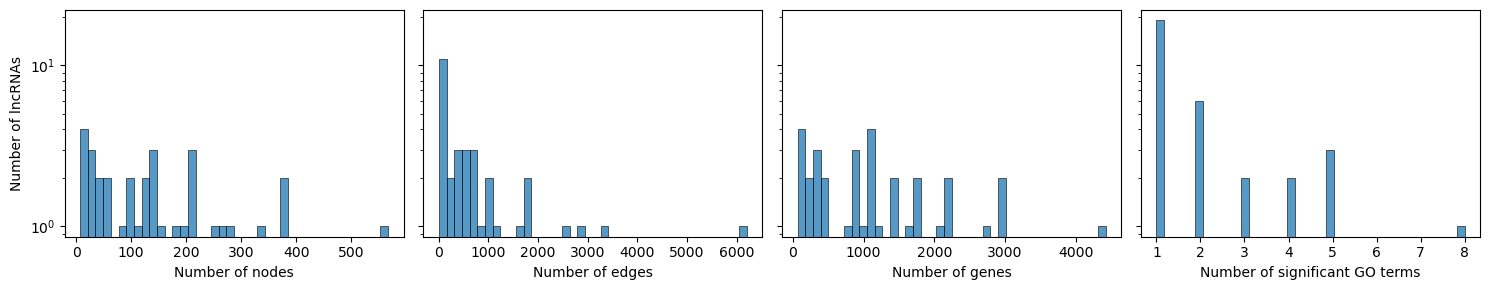

In [135]:
# Represent characteristics of ncRNAs
fig, axes = plt.subplots(1, 4, figsize=(15, 3), sharey=True)

sns.histplot(
    data=ncrna_induced_subnets_df,
    x='n_nodes',
    bins=40,
    ax=axes[0]
)
axes[0].set_xlabel('Number of nodes')
axes[0].set_ylabel('Number of lncRNAs')

sns.histplot(
    data=ncrna_induced_subnets_df,
    x='n_edges',
    bins=40,
    ax=axes[1]
)
axes[1].set_xlabel('Number of edges')
axes[1].set_ylabel('Number of lncRNAs')


sns.histplot(
    data=ncrna_induced_subnets_df,
    x='n_genes',
    bins=40,
    ax=axes[2]
)
axes[2].set_xlabel('Number of genes')
axes[2].set_ylabel('Number of lncRNAs')

sns.histplot(
    data=ncrna_induced_subnets_df,
    x='n_go_terms',
    bins=40,
    ax=axes[3]
)
axes[3].set_xlabel('Number of significant GO terms')
axes[3].set_ylabel('Number of lncRNAs')

plt.yscale('log')
plt.tight_layout()
plt.show()

In [136]:
# Represent each ncRNA by the corresponding significant GO terms
go_ncrna_induced_subnets_df = ncrna_induced_subnets_df[['ncrna', 'go_terms']]
go_ncrna_induced_subnets_df = go_ncrna_induced_subnets_df.explode('go_terms')
go_ncrna_induced_subnets_df = go_ncrna_induced_subnets_df.dropna(subset=['go_terms'])
go_ncrna_induced_subnets_df.loc[:, 'n'] = 1
go_ncrna_induced_subnets_df = go_ncrna_induced_subnets_df.set_index(['ncrna', 'go_terms'])
go_ncrna_induced_subnets_df = go_ncrna_induced_subnets_df.unstack(fill_value=0)
go_ncrna_induced_subnets_df = go_ncrna_induced_subnets_df.droplevel(level=0, axis=1)

In [143]:
from scipy.spatial.distance import pdist
from scipy.cluster.hierarchy import dendrogram, linkage
# Ordering of GO terms

# Identify all GO terms used and the correspondong genes
all_go_terms = go_ncrna_induced_subnets_df.columns.values
url = "https://maayanlab.cloud/Enrichr/geneSetLibrary?mode=json&libraryName=GO_Biological_Process_2023"
go_library = requests.get(url).json()

go_dict = {
    k.split(' ')[-1][1:-1]: v
    for k, v in go_library.items()
}
all_go_term_genes = [go_dict[term] if (term in go_dict.keys()) else [] for term in all_go_terms]

# Build similarity matrix of GO terms based on Jaccard similarity
def jaccard_similarity(set1, set2):
    intersection = len(set1.intersection(set2))
    union = len(set1.union(set2))
    return intersection / union if union != 0 else 0

matrix_size = len(all_go_term_genes)
jaccard_matrix = np.zeros((matrix_size, matrix_size))
for i, j in itertools.combinations(range(matrix_size), 2):
    set_i = set(all_go_term_genes[i])
    set_j = set(all_go_term_genes[j])
    jaccard_matrix[i, j] = jaccard_similarity(set_i, set_j)
    jaccard_matrix[j, i] = jaccard_matrix[i, j]
jaccard_df = pd.DataFrame(jaccard_matrix, index=all_go_terms, columns=all_go_terms)
    
# Order GO terms based on their Jaccard similarity    
condensed_dist = pdist(jaccard_df, metric='euclidean')
linkage_matrix = linkage(condensed_dist, method='ward', metric='euclidean')
dend = dendrogram(linkage_matrix, labels=jaccard_df.index, orientation='right', leaf_font_size=10, no_plot=True)
ordered_indices = dend['leaves']
sorted_all_go_terms = all_go_terms[ordered_indices]
go_ncrna_induced_subnets_df = go_ncrna_induced_subnets_df[sorted_all_go_terms]

### Fig S11e

Columns are ordered slightly differently,

<Figure size 640x480 with 0 Axes>

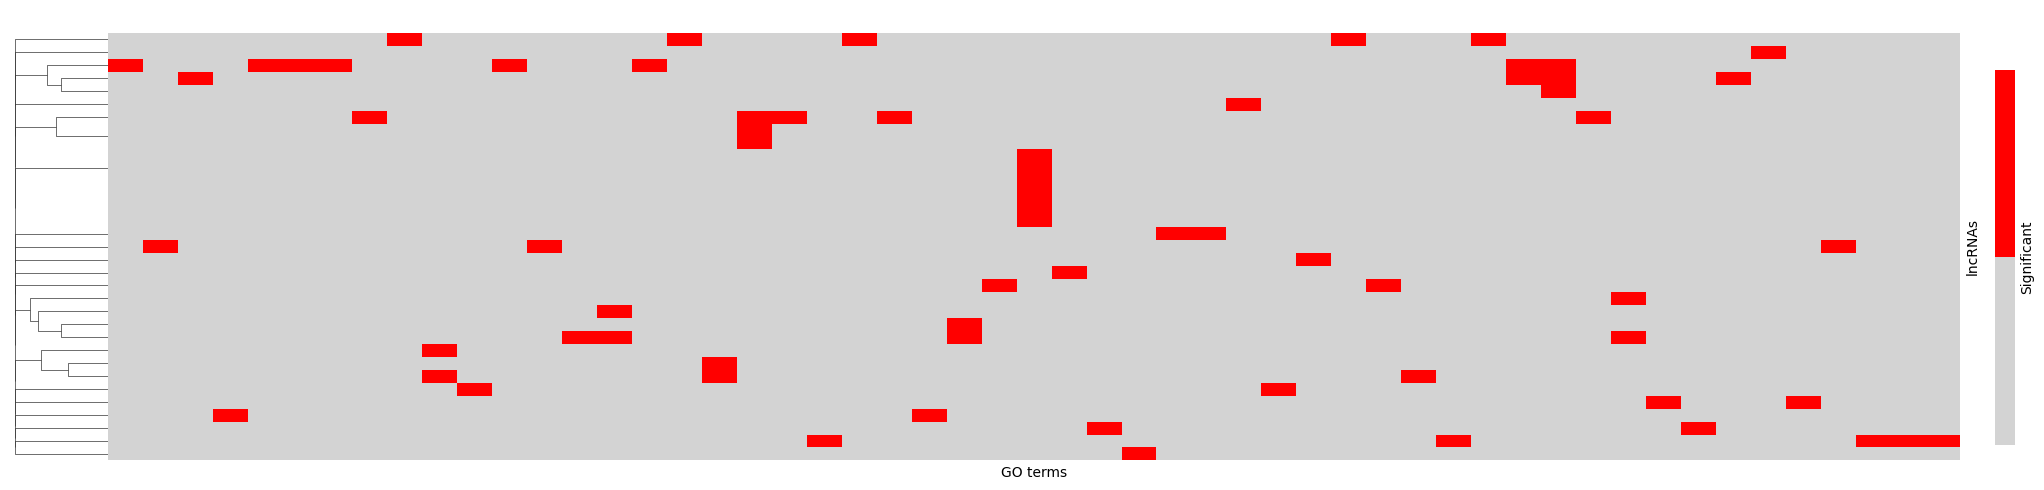

In [150]:
from scipy.cluster.hierarchy import fcluster
from matplotlib.colors import ListedColormap

# Plot as clustermap

# Perform hierarchical clustering of ncRNAs
threshold = 150
row_linkage = linkage(go_ncrna_induced_subnets_df, method='average', metric='cosine')
clusters = fcluster(row_linkage, t=threshold, criterion='maxclust')
unique_clusters = len(set(clusters))
cmap_clusters = ListedColormap(sns.color_palette("husl", n_colors=unique_clusters))
row_colors = [cmap_clusters(cluster) for cluster in clusters]

# Plot clustermap
cmap = ListedColormap(['lightgrey', 'red'])
plt.figure()
clustermap = sns.clustermap(
    data=go_ncrna_induced_subnets_df,
    method='average',
    metric='cosine',
    row_cluster=True,
    col_cluster=False,
    dendrogram_ratio=0.05,
    xticklabels=False,
    yticklabels=False,
    cmap=cmap,
#     cbar=True,
    cbar_kws={'label': 'Significant', 'ticks': []},
    figsize=(20,5)
)
clustermap.ax_cbar.set_position([1, 0.1, 0.01, 0.75])
clustermap.ax_heatmap.set_xlabel('GO terms')
clustermap.ax_heatmap.set_ylabel('lncRNAs')
plt.show()

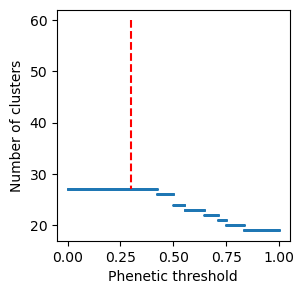

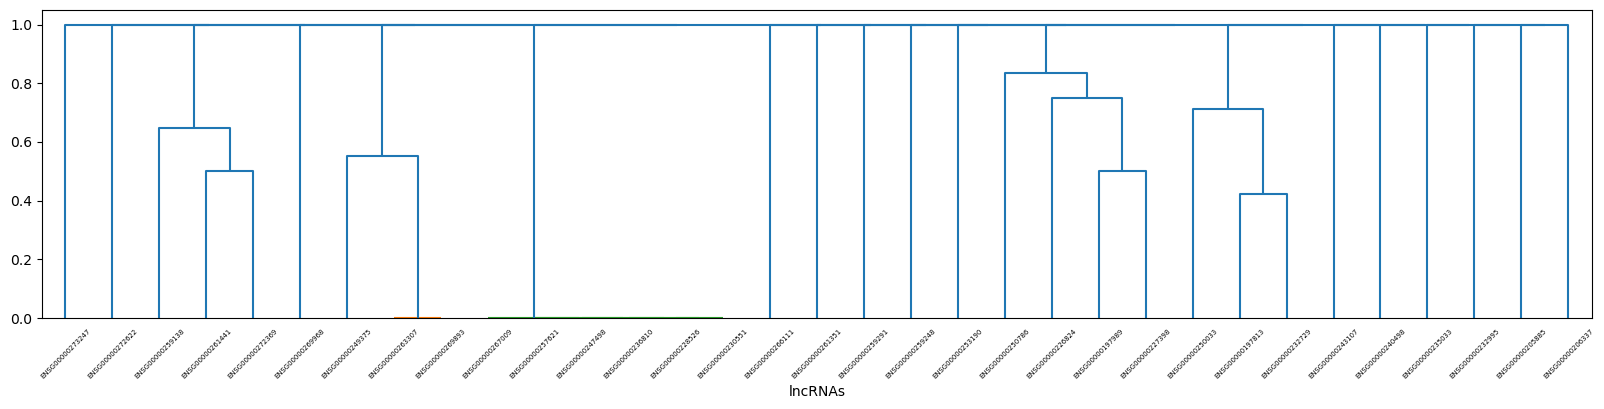

In [170]:
# Cluster ncRNAs based on enriched GO terms
row_linkage = linkage(go_ncrna_induced_subnets_df, method='average', metric='cosine')
t_list = np.arange(0, 1, 0.001)
t_opt = 0.3
n_clusters_list = []
for t in t_list:
    cluster_indices = fcluster(row_linkage, t, criterion='distance')
    n_clusters = len(np.unique(cluster_indices))
    n_clusters_list.append(n_clusters)

plt.figure(figsize=(3,3))
plt.scatter(t_list, n_clusters_list, s=1)
plt.vlines(x=t_opt, ymin=60, ymax=max(n_clusters_list), color='red', linestyle='dashed')
plt.xlabel('Phenetic threshold')
plt.ylabel('Number of clusters')
plt.show()

plt.figure(figsize=(20, 4))
dendrogram(
    row_linkage, 
    labels=go_ncrna_induced_subnets_df.index, 
    leaf_font_size=5,
    color_threshold=t_opt
)
plt.xlabel('lncRNAs')
plt.ylabel('')
plt.show()

In [171]:
# Characterization of clustering
cluster_indices = fcluster(row_linkage, t_opt, criterion='distance')
cluster_ids, cluster_counts = np.unique(cluster_indices, return_counts=True)
nontrivial_clusters = cluster_ids[cluster_counts>1]
print(f'Number of nontrivial clusters = {len(nontrivial_clusters)}')

Number of nontrivial clusters = 2


### Fig S11f

## Load GO terms for analysis

In [199]:
import requests

def fetch_enrichr_library(name):
    url = f"https://maayanlab.cloud/Enrichr/geneSetLibrary?mode=text&libraryName={name}"
    r = requests.get(url)
    r.raise_for_status()
    
    genesets = {}
    for line in r.text.strip().split('\n'):
        parts = line.strip().split('\t')
        if len(parts) >= 3:
            term = parts[0]
            genes = [g.split(',')[0] for g in parts[2:] if g.split(',')[0]]
            genesets[term] = genes
    return genesets

go_bp_dict = fetch_enrichr_library('GO_Biological_Process_2023')

go_terms = list(go_bp_dict.keys())
goid2goterm = {}
for term in go_terms:
    goid = term.split(' ')[-1][1:-1]
    goterm = ' '.join(term.split( )[:-1])
    goid2goterm[goid] = goterm

In [202]:
# GO terms that are the most targeted by ncRNAs
go_terms_df = go_ncrna_induced_subnets_df.sum(axis=0).to_frame('n_ncrna').sort_values(by=['n_ncrna'], ascending=False)
go_terms_df = go_terms_df.reset_index()
go_terms_df.columns = ['go_id', 'n_ncrna']
go_terms_df.loc[:, 'go_term'] = [
    goid2goterm[go_id] if (go_id in goid2goterm.keys()) else '.'
    for go_id in go_terms_df['go_id']
]
go_terms_df.loc[:, 'ncrna'] = [
    go_ncrna_induced_subnets_df[go_ncrna_induced_subnets_df[go_id]==1].index.values
    for go_id in go_terms_df['go_id']
]
go_terms_df = go_terms_df[['go_id', 'go_term', 'n_ncrna', 'ncrna']]
go_terms_df.head()

,go_id,go_term,n_ncrna,ncrna
0,GO:0045109,Intermediate Filament Organization,6,"[ENSG00000228526, ENSG00000230551, ENSG0000023..."
1,GO:0060396,Growth Hormone Receptor Signaling Pathway,3,"[ENSG00000249375, ENSG00000263307, ENSG0000026..."
2,GO:0010526,Retrotransposon Silencing,3,"[ENSG00000259138, ENSG00000261441, ENSG0000027..."
3,GO:0097435,Supramolecular Fiber Organization,2,"[ENSG00000232729, ENSG00000250033]"
4,GO:0046688,Response To Copper Ion,2,"[ENSG00000197989, ENSG00000227398]"


### Fig S11f

In [203]:
latex_output = go_terms_df.to_latex(index=False)
print(latex_output)

\begin{tabular}{llrl}
\toprule
go_id & go_term & n_ncrna & ncrna \\
\midrule
GO:0045109 & Intermediate Filament Organization & 6 & ['ENSG00000228526' 'ENSG00000230551' 'ENSG00000236810' 'ENSG00000247498'
 'ENSG00000257621' 'ENSG00000267009'] \\
GO:0060396 & Growth Hormone Receptor Signaling Pathway & 3 & ['ENSG00000249375' 'ENSG00000263307' 'ENSG00000269893'] \\
GO:0010526 & Retrotransposon Silencing & 3 & ['ENSG00000259138' 'ENSG00000261441' 'ENSG00000272369'] \\
GO:0097435 & Supramolecular Fiber Organization & 2 & ['ENSG00000232729' 'ENSG00000250033'] \\
GO:0046688 & Response To Copper Ion & 2 & ['ENSG00000197989' 'ENSG00000227398'] \\
GO:0060429 & Epithelium Development & 2 & ['ENSG00000197813' 'ENSG00000232729'] \\
GO:0010529 & Negative Regulation Of Transposition & 2 & ['ENSG00000259138' 'ENSG00000261441'] \\
GO:0010043 & Response To Zinc Ion & 2 & ['ENSG00000227398' 'ENSG00000250786'] \\
GO:0071248 & Cellular Response To Metal Ion & 2 & ['ENSG00000226824' 'ENSG00000227398'] \\
GO